Model architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 75, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 75, 128)        │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 75, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 37, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 37, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 18, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 530,433 (2.02 MB)

 Trainable params: 529,153 (2.02 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/100
36/36 - 6s - 161ms/step - accuracy: 0.5801 - auc: 0.6115 - loss: 1.0089 - precision: 0.6435 - recall: 0.6138 - val_accuracy: 0.4574 - val_auc: 0.7540 - val_loss: 0.7174 - val_precision: 1.0000 - val_recall: 0.0613
Epoch 2/100
36/36 - 1s - 29ms/step - accuracy: 0.6290 - auc: 0.6759 - loss: 0.8301 - precision: 0.6951 - recall: 0.6385 - val_accuracy: 0.4965 - val_auc: 0.7269 - val_loss: 0.7310 - val_precision: 0.8182 - val_recall: 0.1656
Epoch 3/100
36/36 - 1s - 28ms/step - accuracy: 0.6406 - auc: 0.6952 - loss: 0.7762 - precision: 0.7003 - recall: 0.6615 - val_accuracy: 0.4929 - val_auc: 0.7599 - val_loss: 0.7430 - val_precision: 0.8333 - val_recall: 0.1534
Epoch 4/100
36/36 - 1s - 28ms/step - accuracy: 0.6495 - auc: 0.7158 - loss: 0.7722 - precision: 0.7270 - recall: 0.6308 - val_accuracy: 0.4929 - val_auc: 0.5519 - val_loss: 0.7259 - val_precision: 0.7941 - val_recall: 0.1656
Epoch 5/100
36/36 - 1s - 32ms/step - accuracy: 0.6477 - auc: 0.6979 - loss: 0.7564 - precision: 0.7

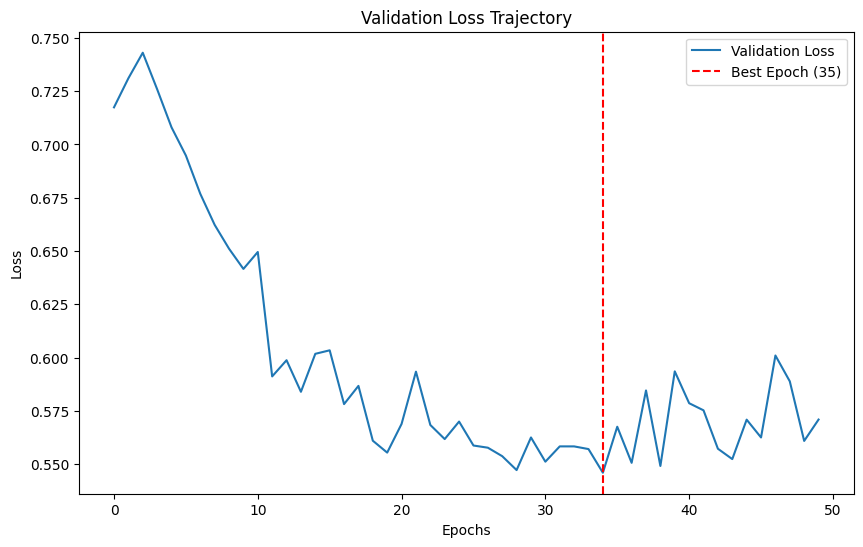

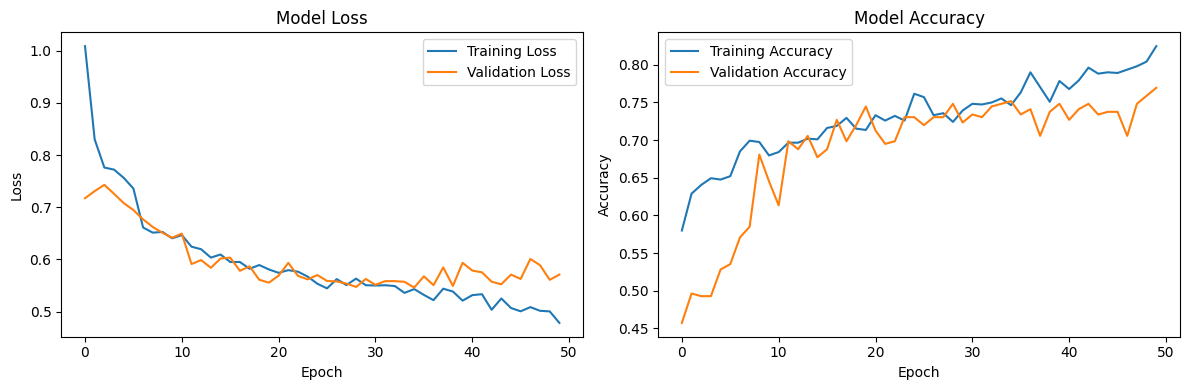


Final evaluation:
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7219 - auc: 0.8196 - loss: 0.5624 - precision: 0.7784 - recall: 0.7270
Metrics Dictionary: {'loss': 0.5704119205474854, 'compile_metrics': 0.7215909361839294}
Manually calculated accuracy: 0.7216

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.70      0.68       149
           1       0.77      0.73      0.75       203

    accuracy                           0.72       352
   macro avg       0.72      0.72      0.72       352
weighted avg       0.72      0.72      0.72       352


Test Metrics Summary:
Test loss: 0.5704
Test compile_metrics: 0.7216
Test accuracy: 0.7216


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(75, 6), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""            
        if self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
        
        elif self.model_type=="model-3":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            x = layers.Conv1D(128 * 2, kernel_size=3, padding="same", activation="relu")(x)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            # BiLSTM
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
            x = layers.BatchNormalization()(x)

            # Dense layers
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.5)(x)

            outputs = layers.Dense(1, activation="sigmoid")(x)

            model = models.Model(inputs, outputs)
    
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,weight_decay=1e-4),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=75, d_model=3):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 225:  # Verify input dimensions
            X = X.reshape(-1, 75, 3)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 3))
        X_train = self.scaler.transform(X_train.reshape(-1, 3)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 3)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        from sklearn.utils import class_weight
        
        class_weights = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_train),
            y=y_train
        )
        class_weights = dict(enumerate(class_weights))

        history = self.model.fit(
            X_train, y_train,
            class_weight=class_weights,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=32,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-3', input_shape=(75, 3))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","eyebrow_features_DeepFakeDetection.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 75, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 75, 128)        │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 75, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 37, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 37, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 18, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 530,433 (2.02 MB)

 Trainable params: 529,153 (2.02 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/100
30/30 - 5s - 178ms/step - accuracy: 0.5248 - auc: 0.5265 - loss: 1.0489 - precision: 0.5274 - recall: 0.4863 - val_accuracy: 0.4748 - val_auc: 0.5504 - val_loss: 0.7099 - val_precision: 0.4862 - val_recall: 0.8908
Epoch 2/100
30/30 - 1s - 30ms/step - accuracy: 0.5068 - auc: 0.5247 - loss: 0.9920 - precision: 0.5079 - recall: 0.4758 - val_accuracy: 0.5126 - val_auc: 0.5260 - val_loss: 0.7102 - val_precision: 0.5067 - val_recall: 0.9496
Epoch 3/100
30/30 - 1s - 29ms/step - accuracy: 0.5121 - auc: 0.5213 - loss: 0.9195 - precision: 0.5133 - recall: 0.4863 - val_accuracy: 0.5126 - val_auc: 0.5275 - val_loss: 0.7084 - val_precision: 0.5068 - val_recall: 0.9328
Epoch 4/100
30/30 - 1s - 28ms/step - accuracy: 0.5037 - auc: 0.5088 - loss: 0.9352 - precision: 0.5041 - recall: 0.5221 - val_accuracy: 0.5588 - val_auc: 0.5557 - val_loss: 0.7065 - val_precision: 0.5833 - val_recall: 0.4118
Epoch 5/100
30/30 - 1s - 26ms/step - accuracy: 0.5269 - auc: 0.5221 - loss: 0.8627 - precision: 0.5

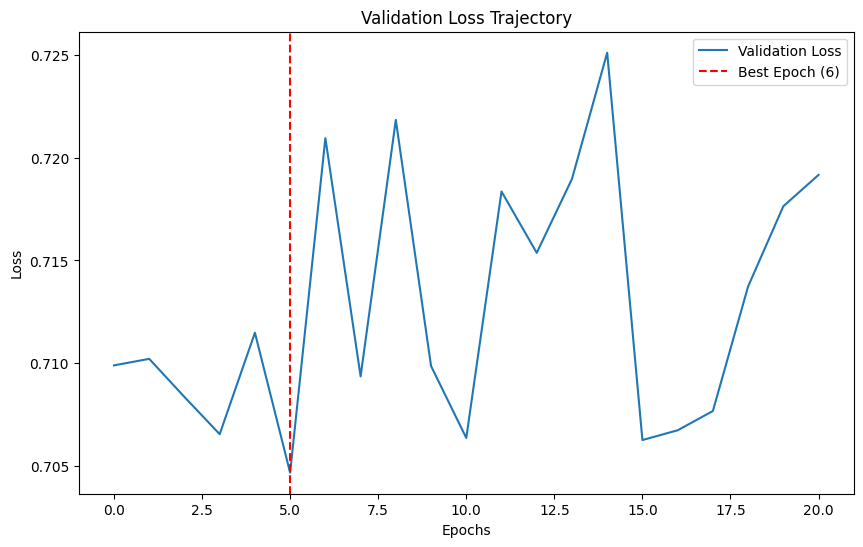

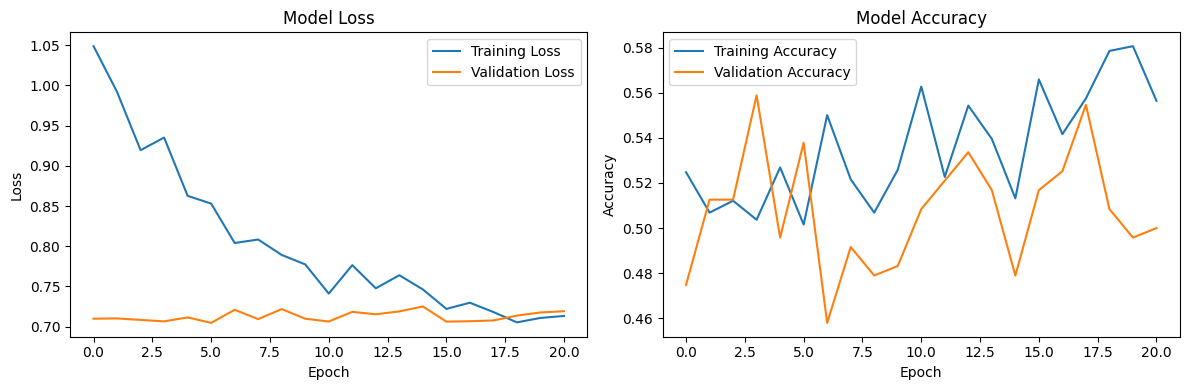


Final evaluation:
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5141 - auc: 0.4929 - loss: 0.7118 - precision: 0.4710 - recall: 0.4682
Metrics Dictionary: {'loss': 0.7105327844619751, 'compile_metrics': 0.5252525210380554}
Manually calculated accuracy: 0.5253

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.58      0.55       149
           1       0.53      0.47      0.49       148

    accuracy                           0.53       297
   macro avg       0.53      0.53      0.52       297
weighted avg       0.53      0.53      0.52       297


Test Metrics Summary:
Test loss: 0.7105
Test compile_metrics: 0.5253
Test accuracy: 0.5253


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(75, 6), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""            
        if self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
        elif self.model_type=="model-2":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            # Expand dims
            x = layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs)

            def squeeze_excite_block(inputs, ratio=16):
                filters = inputs.shape[-1]
                
                se = layers.GlobalAveragePooling2D()(inputs)  # 🛠 2D pooling for 4D input
                se = layers.Reshape((1, 1, filters))(se)
                se = layers.Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
                se = layers.Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)
                x = layers.Multiply()([inputs, se])
                return x

            # --- CNN Feature Extractor ---
            x = layers.TimeDistributed(layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = layers.TimeDistributed(layers.BatchNormalization())(x)
            x = squeeze_excite_block(x)
            x = layers.TimeDistributed(layers.MaxPooling1D(2))(x)

            x = layers.TimeDistributed(layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = layers.TimeDistributed(layers.BatchNormalization())(x)
            x = squeeze_excite_block(x)

            x = layers.TimeDistributed(layers.Flatten())(x)  # (75, features)

            # --- BiLSTM ---
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
            x = layers.LayerNormalization()(x)

            # --- Transformer Block ---
            def transformer_block(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1):
                attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
                attn_output = layers.Dropout(dropout)(attn_output)
                x = layers.Add()([x, attn_output])
                x = layers.LayerNormalization()(x)

                ff_output = layers.Dense(ff_dim, activation='relu')(x)
                ff_output = layers.Dense(x.shape[-1])(ff_output)
                ff_output = layers.Dropout(dropout)(ff_output)
                x = layers.Add()([x, ff_output])
                x = layers.LayerNormalization()(x)
                return x

            x = transformer_block(x)
            x = transformer_block(x)

            x = layers.GlobalAveragePooling1D()(x)

            # --- Head ---
            x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.6)(x)
            x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.3)(x)

            outputs = layers.Dense(1, activation='sigmoid')(x)

            model = models.Model(inputs, outputs)
        elif self.model_type=="model-3":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            x = layers.Conv1D(128 * 2, kernel_size=3, padding="same", activation="relu")(x)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            # BiLSTM
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
            x = layers.BatchNormalization()(x)

            # Dense layers
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.5)(x)

            outputs = layers.Dense(1, activation="sigmoid")(x)

            model = models.Model(inputs, outputs)
    
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,weight_decay=1e-4),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=75, d_model=3):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 225:  # Verify input dimensions
            X = X.reshape(-1, 75, 3)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 3))
        X_train = self.scaler.transform(X_train.reshape(-1, 3)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 3)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        from sklearn.utils import class_weight
        
        class_weights = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_train),
            y=y_train
        )
        class_weights = dict(enumerate(class_weights))

        history = self.model.fit(
            X_train, y_train,
            class_weight=class_weights,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=32,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-3', input_shape=(75, 3))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","eyebrow_features_Face2Face.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_22 (InputLayer)     │ (None, 75, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_44 (Conv1D)              │ (None, 75, 128)        │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_59          │ (None, 75, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_37 (MaxPooling1D) │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_45 (Conv1D)              │ (None, 37, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_60          │ (None, 37, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_38 (MaxPooling1D) │ (None, 18, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_16                │ (None, 256)            │       394,240 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_61          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 530,433 (2.02 MB)

 Trainable params: 529,153 (2.02 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/100
27/27 - 5s - 171ms/step - accuracy: 0.5229 - auc: 0.5274 - loss: 1.1066 - precision: 0.4602 - recall: 0.4274 - val_accuracy: 0.4393 - val_auc: 0.4577 - val_loss: 0.7264 - val_precision: 0.4365 - val_recall: 0.9053
Epoch 2/100
27/27 - 1s - 26ms/step - accuracy: 0.5475 - auc: 0.5591 - loss: 0.9982 - precision: 0.4918 - recall: 0.5541 - val_accuracy: 0.4393 - val_auc: 0.5296 - val_loss: 0.7361 - val_precision: 0.4413 - val_recall: 0.9895
Epoch 3/100
27/27 - 1s - 26ms/step - accuracy: 0.5100 - auc: 0.5101 - loss: 1.0522 - precision: 0.4521 - recall: 0.4855 - val_accuracy: 0.4346 - val_auc: 0.5701 - val_loss: 0.7413 - val_precision: 0.4343 - val_recall: 0.9053
Epoch 4/100
27/27 - 1s - 29ms/step - accuracy: 0.5299 - auc: 0.5437 - loss: 0.9335 - precision: 0.4748 - recall: 0.5462 - val_accuracy: 0.4626 - val_auc: 0.5595 - val_loss: 0.7228 - val_precision: 0.4519 - val_recall: 0.9895
Epoch 5/100
27/27 - 1s - 30ms/step - accuracy: 0.5369 - auc: 0.5426 - loss: 0.8997 - precision: 0.4

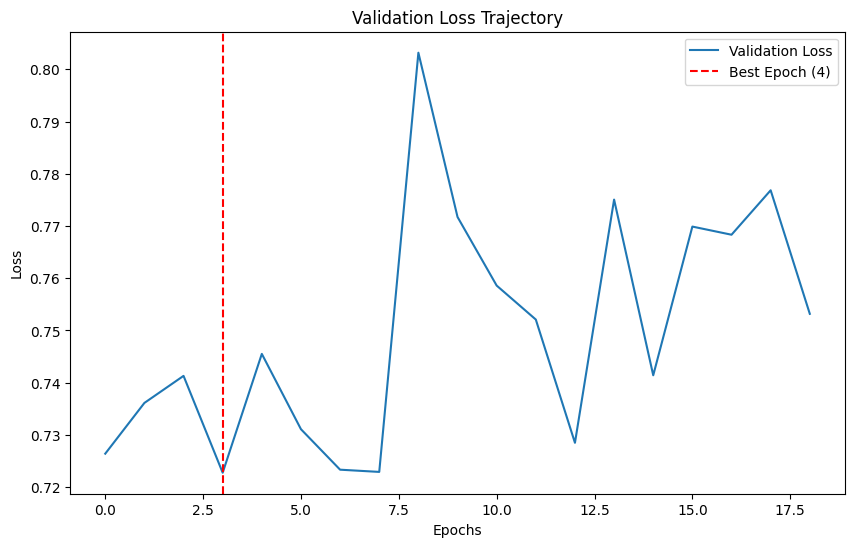

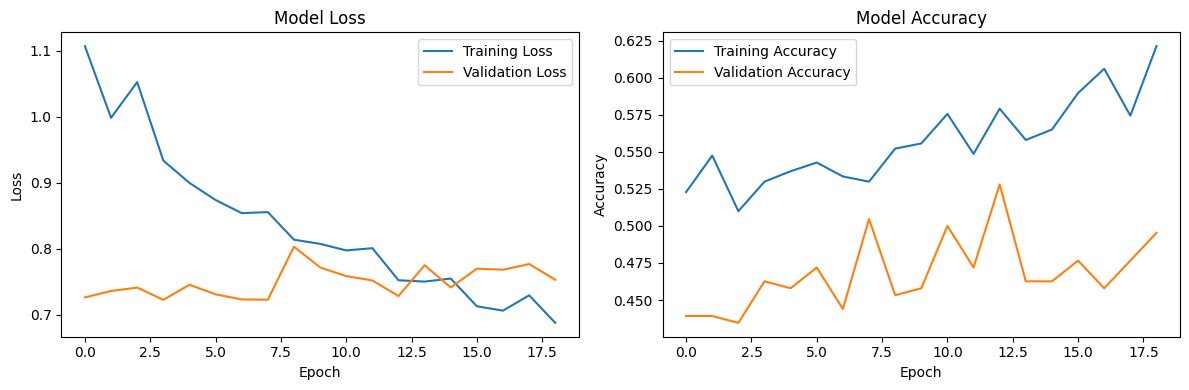


Final evaluation:
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4443 - auc: 0.5374 - loss: 0.7244 - precision: 0.4314 - recall: 0.9709
Metrics Dictionary: {'loss': 0.7217263579368591, 'compile_metrics': 0.449438214302063}
Manually calculated accuracy: 0.4494

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.05      0.09       149
           1       0.44      0.96      0.61       118

    accuracy                           0.45       267
   macro avg       0.51      0.50      0.35       267
weighted avg       0.52      0.45      0.32       267


Test Metrics Summary:
Test loss: 0.7217
Test compile_metrics: 0.4494
Test accuracy: 0.4494


In [23]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(75, 6), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""            
        if self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
        
        elif self.model_type=="model-3":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            x = layers.Conv1D(128 * 2, kernel_size=3, padding="same", activation="relu")(x)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            # BiLSTM
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
            x = layers.BatchNormalization()(x)

            # Dense layers
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.5)(x)

            outputs = layers.Dense(1, activation="sigmoid")(x)

            model = models.Model(inputs, outputs)
    
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,weight_decay=1e-4),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=75, d_model=3):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 225:  # Verify input dimensions
            X = X.reshape(-1, 75, 3)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 3))
        X_train = self.scaler.transform(X_train.reshape(-1, 3)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 3)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        from sklearn.utils import class_weight
        
        class_weights = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_train),
            y=y_train
        )
        class_weights = dict(enumerate(class_weights))

        history = self.model.fit(
            X_train, y_train,
            class_weight=class_weights,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=32,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-3', input_shape=(75, 3))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","eyebrow_features_FaceSwap.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_23 (InputLayer)     │ (None, 75, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_46 (Conv1D)              │ (None, 75, 128)        │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_62          │ (None, 75, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_39 (MaxPooling1D) │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_47 (Conv1D)              │ (None, 37, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_63          │ (None, 37, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_40 (MaxPooling1D) │ (None, 18, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_17                │ (None, 256)            │       394,240 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_64          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 530,433 (2.02 MB)

 Trainable params: 529,153 (2.02 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/100
30/30 - 5s - 159ms/step - accuracy: 0.4731 - auc: 0.4786 - loss: 1.1239 - precision: 0.4709 - recall: 0.4253 - val_accuracy: 0.5252 - val_auc: 0.5375 - val_loss: 0.7101 - val_precision: 0.5147 - val_recall: 0.8824
Epoch 2/100
30/30 - 1s - 28ms/step - accuracy: 0.5153 - auc: 0.5187 - loss: 0.9774 - precision: 0.5163 - recall: 0.5011 - val_accuracy: 0.5000 - val_auc: 0.5236 - val_loss: 0.7171 - val_precision: 0.5000 - val_recall: 0.7983
Epoch 3/100
30/30 - 1s - 26ms/step - accuracy: 0.5216 - auc: 0.5074 - loss: 0.9420 - precision: 0.5216 - recall: 0.5326 - val_accuracy: 0.4916 - val_auc: 0.4990 - val_loss: 0.7127 - val_precision: 0.4933 - val_recall: 0.6218
Epoch 4/100
30/30 - 1s - 27ms/step - accuracy: 0.4984 - auc: 0.4966 - loss: 0.9144 - precision: 0.4989 - recall: 0.4758 - val_accuracy: 0.5084 - val_auc: 0.5304 - val_loss: 0.7115 - val_precision: 0.5132 - val_recall: 0.3277
Epoch 5/100
30/30 - 1s - 27ms/step - accuracy: 0.4984 - auc: 0.5050 - loss: 0.8892 - precision: 0.4

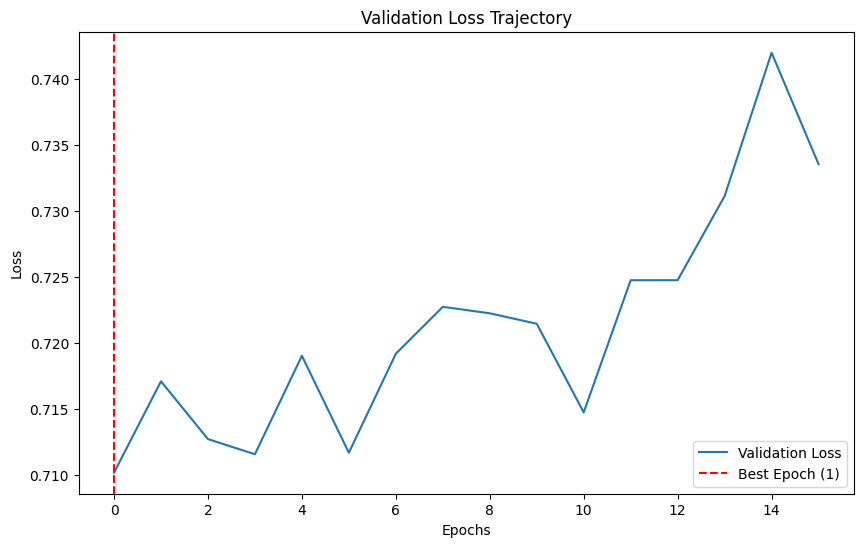

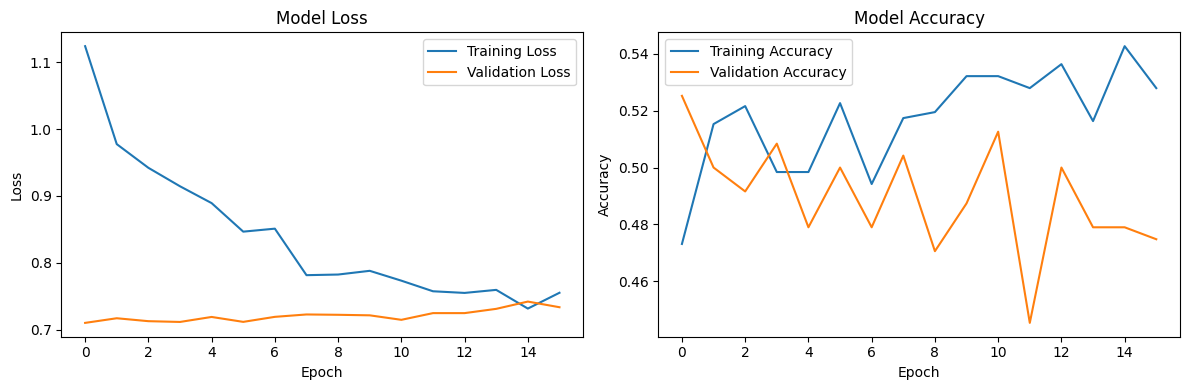


Final evaluation:
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4449 - auc: 0.4449 - loss: 0.7201 - precision: 0.4483 - recall: 0.8926
Metrics Dictionary: {'loss': 0.7157846689224243, 'compile_metrics': 0.48821547627449036}
Manually calculated accuracy: 0.4882

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.12      0.19       149
           1       0.49      0.86      0.63       148

    accuracy                           0.49       297
   macro avg       0.48      0.49      0.41       297
weighted avg       0.48      0.49      0.41       297


Test Metrics Summary:
Test loss: 0.7158
Test compile_metrics: 0.4882
Test accuracy: 0.4882


In [24]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(75, 6), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""            
        if self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
        
        elif self.model_type=="model-3":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            x = layers.Conv1D(128 * 2, kernel_size=3, padding="same", activation="relu")(x)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            # BiLSTM
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
            x = layers.BatchNormalization()(x)

            # Dense layers
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.5)(x)

            outputs = layers.Dense(1, activation="sigmoid")(x)

            model = models.Model(inputs, outputs)
    
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,weight_decay=1e-4),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=75, d_model=3):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 225:  # Verify input dimensions
            X = X.reshape(-1, 75, 3)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 3))
        X_train = self.scaler.transform(X_train.reshape(-1, 3)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 3)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        from sklearn.utils import class_weight
        
        class_weights = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_train),
            y=y_train
        )
        class_weights = dict(enumerate(class_weights))

        history = self.model.fit(
            X_train, y_train,
            class_weight=class_weights,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=32,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-3', input_shape=(75, 3))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","eyebrow_features_deepfake.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_12 (Conv1D)              │ (None, 75, 64)         │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 75, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_11 (MaxPooling1D) │ (None, 37, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 37, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 37, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,433 (134.50 KB)

 Trainable params: 34,049 (133.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
30/30 - 2s - 73ms/step - accuracy: 0.4932 - auc: 0.5035 - loss: 0.7542 - precision: 0.4929 - recall: 0.4400 - val_accuracy: 0.4664 - val_auc: 0.5052 - val_loss: 0.6936 - val_precision: 0.4697 - val_recall: 0.5210
Epoch 2/100
30/30 - 0s - 9ms/step - accuracy: 0.5353 - auc: 0.5348 - loss: 0.7280 - precision: 0.5329 - recall: 0.5789 - val_accuracy: 0.5126 - val_auc: 0.5502 - val_loss: 0.6920 - val_precision: 0.5366 - val_recall: 0.1849
Epoch 3/100
30/30 - 0s - 8ms/step - accuracy: 0.5311 - auc: 0.5537 - loss: 0.7014 - precision: 0.5307 - recall: 0.5453 - val_accuracy: 0.5084 - val_auc: 0.5251 - val_loss: 0.6930 - val_precision: 1.0000 - val_recall: 0.0168
Epoch 4/100
30/30 - 0s - 8ms/step - accuracy: 0.5669 - auc: 0.5871 - loss: 0.6884 - precision: 0.5632 - recall: 0.6000 - val_accuracy: 0.5000 - val_auc: 0.4946 - val_loss: 0.7014 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/100
30/30 - 0s - 8ms/step - accuracy: 0.5501 - auc: 0.5656 - loss: 0.7093 - precision: 

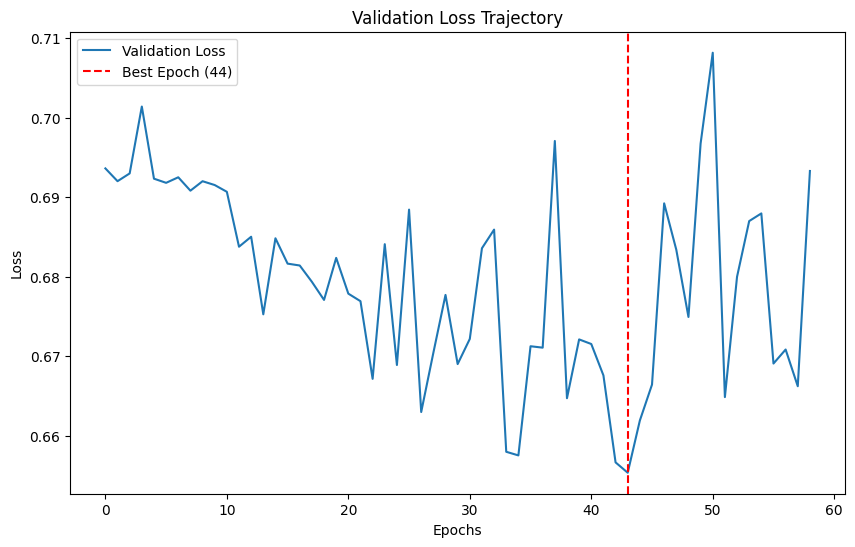

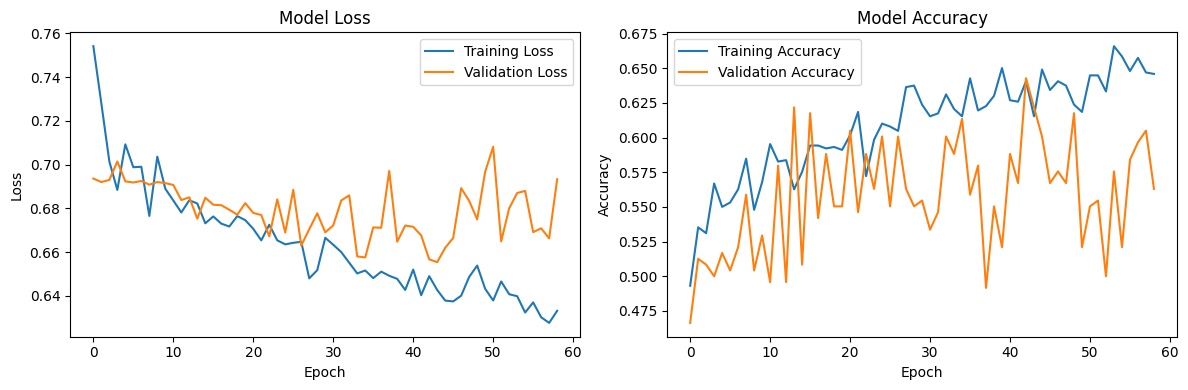


Final evaluation:
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6135 - auc: 0.6453 - loss: 0.6613 - precision: 0.5931 - recall: 0.4758 
Metrics Dictionary: {'loss': 0.6648922562599182, 'compile_metrics': 0.5993266105651855}
Manually calculated accuracy: 0.5993

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.70      0.64       149
           1       0.62      0.50      0.55       148

    accuracy                           0.60       297
   macro avg       0.60      0.60      0.60       297
weighted avg       0.60      0.60      0.60       297


Test Metrics Summary:
Test loss: 0.6649
Test compile_metrics: 0.5993
Test accuracy: 0.5993


In [7]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(75, 6), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""            
        if self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
        elif self.model_type=="model-2":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            # Expand dims
            x = layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs)

            def squeeze_excite_block(inputs, ratio=16):
                filters = inputs.shape[-1]
                
                se = layers.GlobalAveragePooling2D()(inputs)  # 🛠 2D pooling for 4D input
                se = layers.Reshape((1, 1, filters))(se)
                se = layers.Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
                se = layers.Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)
                x = layers.Multiply()([inputs, se])
                return x

            # --- CNN Feature Extractor ---
            x = layers.TimeDistributed(layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = layers.TimeDistributed(layers.BatchNormalization())(x)
            x = squeeze_excite_block(x)
            x = layers.TimeDistributed(layers.MaxPooling1D(2))(x)

            x = layers.TimeDistributed(layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = layers.TimeDistributed(layers.BatchNormalization())(x)
            x = squeeze_excite_block(x)

            x = layers.TimeDistributed(layers.Flatten())(x)  # (75, features)

            # --- BiLSTM ---
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
            x = layers.LayerNormalization()(x)

            # --- Transformer Block ---
            def transformer_block(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1):
                attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
                attn_output = layers.Dropout(dropout)(attn_output)
                x = layers.Add()([x, attn_output])
                x = layers.LayerNormalization()(x)

                ff_output = layers.Dense(ff_dim, activation='relu')(x)
                ff_output = layers.Dense(x.shape[-1])(ff_output)
                ff_output = layers.Dropout(dropout)(ff_output)
                x = layers.Add()([x, ff_output])
                x = layers.LayerNormalization()(x)
                return x

            x = transformer_block(x)
            x = transformer_block(x)

            x = layers.GlobalAveragePooling1D()(x)

            # --- Head ---
            x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.6)(x)
            x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.3)(x)

            outputs = layers.Dense(1, activation='sigmoid')(x)

            model = models.Model(inputs, outputs)
        elif self.model_type=="model-3":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            x = layers.Conv1D(128 * 2, kernel_size=3, padding="same", activation="relu")(x)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            # BiLSTM
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
            x = layers.BatchNormalization()(x)

            # Dense layers
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.5)(x)

            outputs = layers.Dense(1, activation="sigmoid")(x)

            model = models.Model(inputs, outputs)
    
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,weight_decay=1e-4),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=75, d_model=3):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 225:  # Verify input dimensions
            X = X.reshape(-1, 75, 3)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 3))
        X_train = self.scaler.transform(X_train.reshape(-1, 3)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 3)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        from sklearn.utils import class_weight
        
        class_weights = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_train),
            y=y_train
        )
        class_weights = dict(enumerate(class_weights))

        history = self.model.fit(
            X_train, y_train,
            class_weight=class_weights,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=32,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='cnn', input_shape=(75, 3))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","eyebrow_features_deepfake.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_24 (Conv1D)              │ (None, 75, 64)         │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 75, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_18 (MaxPooling1D) │ (None, 37, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_25 (Conv1D)              │ (None, 37, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 37, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_6      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,433 (134.50 KB)

 Trainable params: 34,049 (133.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
27/27 - 3s - 101ms/step - accuracy: 0.5615 - auc: 0.5724 - loss: 0.7243 - precision: 0.5056 - recall: 0.5963 - val_accuracy: 0.4533 - val_auc: 0.4679 - val_loss: 0.6991 - val_precision: 0.4402 - val_recall: 0.8526
Epoch 2/100
27/27 - 0s - 9ms/step - accuracy: 0.5580 - auc: 0.5848 - loss: 0.7076 - precision: 0.5023 - recall: 0.5752 - val_accuracy: 0.4393 - val_auc: 0.5063 - val_loss: 0.7062 - val_precision: 0.4365 - val_recall: 0.9053
Epoch 3/100
27/27 - 0s - 9ms/step - accuracy: 0.5768 - auc: 0.6058 - loss: 0.6875 - precision: 0.5194 - recall: 0.6359 - val_accuracy: 0.4393 - val_auc: 0.4962 - val_loss: 0.7131 - val_precision: 0.4384 - val_recall: 0.9368
Epoch 4/100
27/27 - 0s - 9ms/step - accuracy: 0.5897 - auc: 0.6362 - loss: 0.6742 - precision: 0.5298 - recall: 0.6807 - val_accuracy: 0.4393 - val_auc: 0.5517 - val_loss: 0.7130 - val_precision: 0.4384 - val_recall: 0.9368
Epoch 5/100
27/27 - 0s - 8ms/step - accuracy: 0.6049 - auc: 0.6503 - loss: 0.6660 - precision: 0.5463 

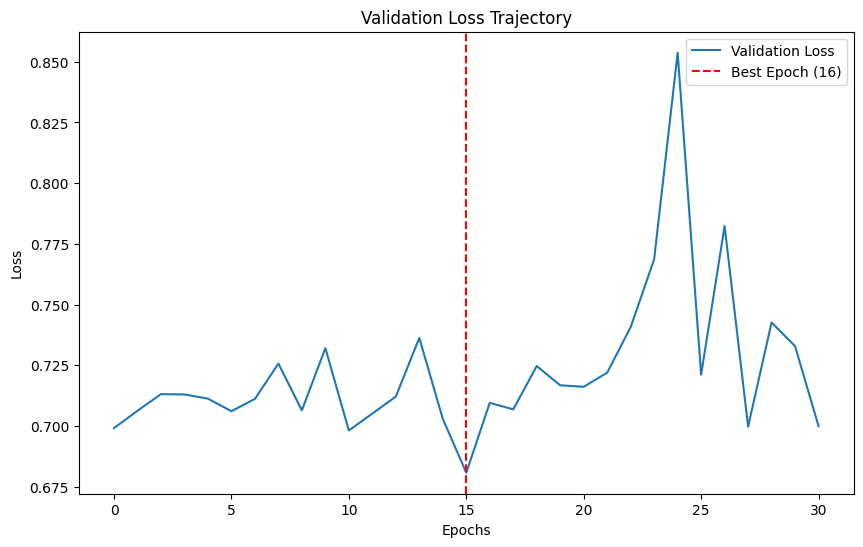

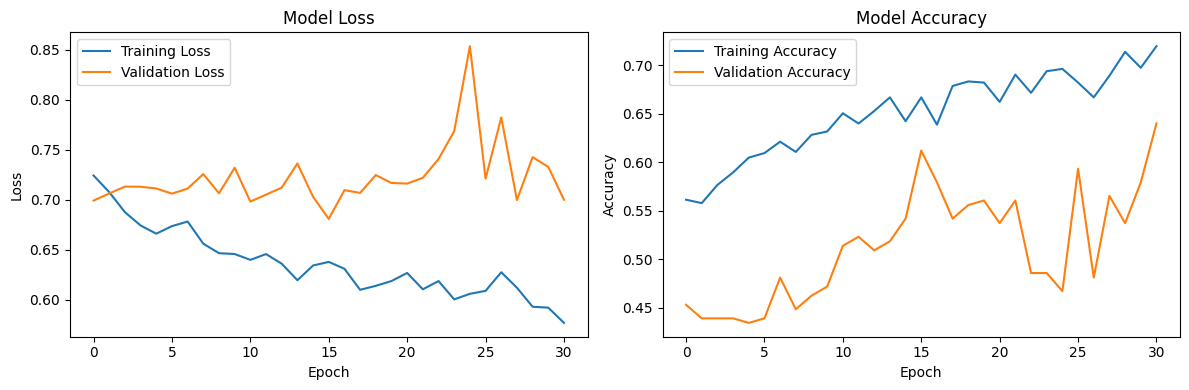


Final evaluation:
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5769 - auc: 0.6062 - loss: 0.6824 - precision: 0.5029 - recall: 0.7045 
Metrics Dictionary: {'loss': 0.6850082874298096, 'compile_metrics': 0.5992509126663208}
Manually calculated accuracy: 0.5993

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.50      0.58       149
           1       0.53      0.72      0.61       118

    accuracy                           0.60       267
   macro avg       0.61      0.61      0.60       267
weighted avg       0.62      0.60      0.60       267


Test Metrics Summary:
Test loss: 0.6850
Test compile_metrics: 0.5993
Test accuracy: 0.5993


In [13]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(75, 6), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""            
        if self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
        elif self.model_type=="model-2":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            # Expand dims
            x = layers.Lambda(lambda x: tf.expand_dims(x, axis=-1))(inputs)

            def squeeze_excite_block(inputs, ratio=16):
                filters = inputs.shape[-1]
                
                se = layers.GlobalAveragePooling2D()(inputs)  # 🛠 2D pooling for 4D input
                se = layers.Reshape((1, 1, filters))(se)
                se = layers.Dense(filters // ratio, activation='relu', kernel_initializer='he_normal', use_bias=False)(se)
                se = layers.Dense(filters, activation='sigmoid', kernel_initializer='he_normal', use_bias=False)(se)
                x = layers.Multiply()([inputs, se])
                return x

            # --- CNN Feature Extractor ---
            x = layers.TimeDistributed(layers.Conv1D(64, 3, activation='relu', padding='same'))(x)
            x = layers.TimeDistributed(layers.BatchNormalization())(x)
            x = squeeze_excite_block(x)
            x = layers.TimeDistributed(layers.MaxPooling1D(2))(x)

            x = layers.TimeDistributed(layers.Conv1D(128, 3, activation='relu', padding='same'))(x)
            x = layers.TimeDistributed(layers.BatchNormalization())(x)
            x = squeeze_excite_block(x)

            x = layers.TimeDistributed(layers.Flatten())(x)  # (75, features)

            # --- BiLSTM ---
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(x)
            x = layers.LayerNormalization()(x)

            # --- Transformer Block ---
            def transformer_block(x, head_size=64, num_heads=4, ff_dim=128, dropout=0.1):
                attn_output = layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout)(x, x)
                attn_output = layers.Dropout(dropout)(attn_output)
                x = layers.Add()([x, attn_output])
                x = layers.LayerNormalization()(x)

                ff_output = layers.Dense(ff_dim, activation='relu')(x)
                ff_output = layers.Dense(x.shape[-1])(ff_output)
                ff_output = layers.Dropout(dropout)(ff_output)
                x = layers.Add()([x, ff_output])
                x = layers.LayerNormalization()(x)
                return x

            x = transformer_block(x)
            x = transformer_block(x)

            x = layers.GlobalAveragePooling1D()(x)

            # --- Head ---
            x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.6)(x)
            x = layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.3)(x)

            outputs = layers.Dense(1, activation='sigmoid')(x)

            model = models.Model(inputs, outputs)
        elif self.model_type=="model-3":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            x = layers.Conv1D(128 * 2, kernel_size=3, padding="same", activation="relu")(x)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            # BiLSTM
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
            x = layers.BatchNormalization()(x)

            # Dense layers
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.5)(x)

            outputs = layers.Dense(1, activation="sigmoid")(x)

            model = models.Model(inputs, outputs)
    
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,weight_decay=1e-4),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=75, d_model=3):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 225:  # Verify input dimensions
            X = X.reshape(-1, 75, 3)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 3))
        X_train = self.scaler.transform(X_train.reshape(-1, 3)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 3)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        from sklearn.utils import class_weight
        
        class_weights = class_weight.compute_class_weight(
            class_weight='balanced',
            classes=np.unique(y_train),
            y=y_train
        )
        class_weights = dict(enumerate(class_weights))

        history = self.model.fit(
            X_train, y_train,
            class_weight=class_weights,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=32,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='cnn', input_shape=(75, 3))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","eyebrow_features_FaceSwap.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 75, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_26 (Conv1D)              │ (None, 75, 128)        │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 75, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_19 (MaxPooling1D) │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_27 (Conv1D)              │ (None, 37, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 37, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_20 (MaxPooling1D) │ (None, 18, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,353 (2.03 MB)

 Trainable params: 531,073 (2.03 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/100
15/15 - 5s - 318ms/step - accuracy: 0.5553 - auc: 0.5629 - loss: 1.0688 - precision: 0.5598 - recall: 0.5221 - val_accuracy: 0.5966 - val_auc: 0.6417 - val_loss: 0.6974 - val_precision: 0.6620 - val_recall: 0.3950
Epoch 2/100
15/15 - 1s - 53ms/step - accuracy: 0.6154 - auc: 0.6633 - loss: 0.8478 - precision: 0.6170 - recall: 0.6105 - val_accuracy: 0.5630 - val_auc: 0.6291 - val_loss: 0.6935 - val_precision: 0.5503 - val_recall: 0.6891
Epoch 3/100
15/15 - 1s - 50ms/step - accuracy: 0.6133 - auc: 0.6489 - loss: 0.8375 - precision: 0.6107 - recall: 0.6274 - val_accuracy: 0.5714 - val_auc: 0.5990 - val_loss: 0.6977 - val_precision: 0.5436 - val_recall: 0.8908
Epoch 4/100
15/15 - 1s - 57ms/step - accuracy: 0.6164 - auc: 0.6401 - loss: 0.8236 - precision: 0.6095 - recall: 0.6505 - val_accuracy: 0.5798 - val_auc: 0.6294 - val_loss: 0.6927 - val_precision: 0.5590 - val_recall: 0.7563
Epoch 5/100
15/15 - 1s - 49ms/step - accuracy: 0.6375 - auc: 0.6822 - loss: 0.7830 - precision: 0.6

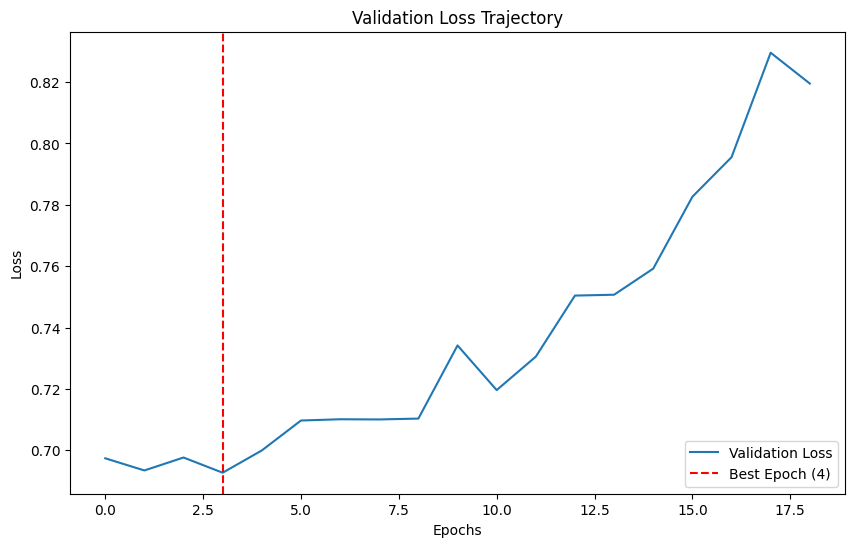

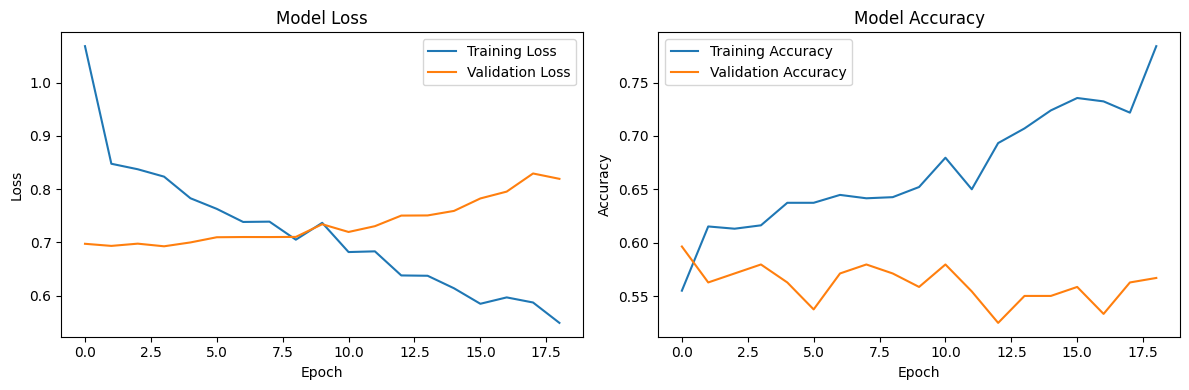


Final evaluation:
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6149 - auc: 0.7078 - loss: 0.6743 - precision: 0.5528 - recall: 0.8176
Metrics Dictionary: {'loss': 0.6720812916755676, 'compile_metrics': 0.6060606241226196}
Manually calculated accuracy: 0.6061

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.42      0.51       149
           1       0.58      0.80      0.67       148

    accuracy                           0.61       297
   macro avg       0.62      0.61      0.59       297
weighted avg       0.62      0.61      0.59       297


Test Metrics Summary:
Test loss: 0.6721
Test compile_metrics: 0.6061
Test accuracy: 0.6061


In [14]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
# from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(75, 6), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""            
        if self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
        
        elif self.model_type=="model-3":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            x = layers.Conv1D(128 * 2, kernel_size=3, padding="same", activation="relu")(x)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            # BiLSTM
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
            x = layers.BatchNormalization()(x)

            # Dense layers
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.5)(x)

            outputs = layers.Dense(1, activation="sigmoid")(x)

            model = models.Model(inputs, outputs)
    
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,weight_decay=1e-4),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=75, d_model=6):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 450:  # Verify input dimensions
            X = X.reshape(-1, 75, 6)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 6))
        X_train = self.scaler.transform(X_train.reshape(-1, 6)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 6)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-3', input_shape=(75, 6))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","eyeblink_dataset-deepfake.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 75, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_30 (Conv1D)              │ (None, 75, 128)        │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_38          │ (None, 75, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_23 (MaxPooling1D) │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_31 (Conv1D)              │ (None, 37, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_39          │ (None, 37, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_24 (MaxPooling1D) │ (None, 18, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_9 (Bidirectional) │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,353 (2.03 MB)

 Trainable params: 531,073 (2.03 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/100
18/18 - 5s - 264ms/step - accuracy: 0.5504 - auc: 0.5876 - loss: 0.9504 - precision: 0.6328 - recall: 0.5395 - val_accuracy: 0.6338 - val_auc: 0.6205 - val_loss: 0.6874 - val_precision: 0.6432 - val_recall: 0.8303
Epoch 2/100
18/18 - 1s - 66ms/step - accuracy: 0.6007 - auc: 0.6352 - loss: 0.8530 - precision: 0.6476 - recall: 0.6869 - val_accuracy: 0.6232 - val_auc: 0.6320 - val_loss: 0.6796 - val_precision: 0.6381 - val_recall: 0.8121
Epoch 3/100
18/18 - 1s - 55ms/step - accuracy: 0.6087 - auc: 0.6318 - loss: 0.8300 - precision: 0.6574 - recall: 0.6824 - val_accuracy: 0.6056 - val_auc: 0.6515 - val_loss: 0.6785 - val_precision: 0.6109 - val_recall: 0.8848
Epoch 4/100
18/18 - 1s - 49ms/step - accuracy: 0.6422 - auc: 0.6981 - loss: 0.7403 - precision: 0.6908 - recall: 0.6960 - val_accuracy: 0.6197 - val_auc: 0.6582 - val_loss: 0.6726 - val_precision: 0.6126 - val_recall: 0.9394
Epoch 5/100
18/18 - 1s - 45ms/step - accuracy: 0.6369 - auc: 0.6853 - loss: 0.7574 - precision: 0.6

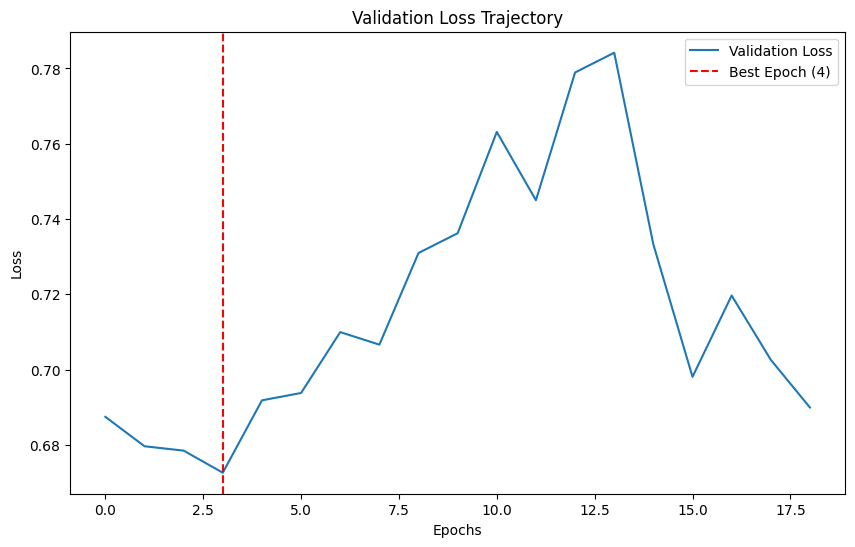

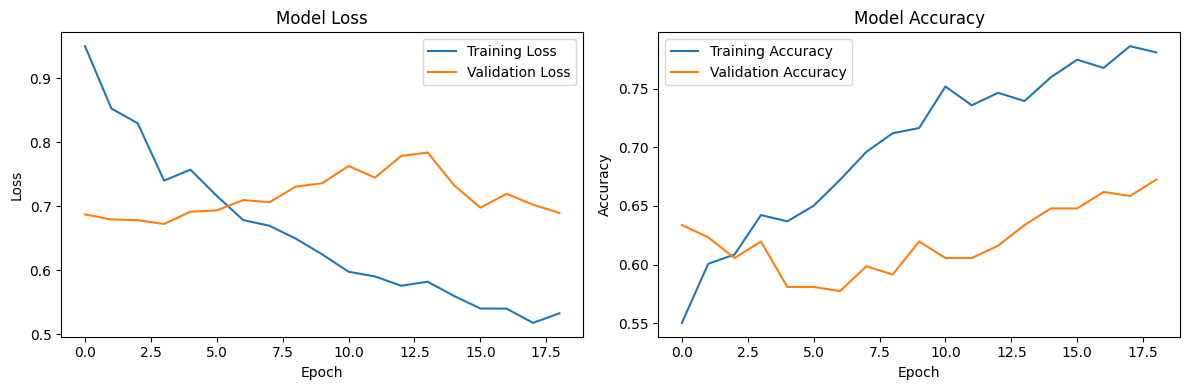


Final evaluation:
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5551 - auc: 0.5536 - loss: 0.7061 - precision: 0.5671 - recall: 0.9194
Metrics Dictionary: {'loss': 0.6899399757385254, 'compile_metrics': 0.5887324213981628}
Manually calculated accuracy: 0.5887

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.10      0.17       149
           1       0.59      0.94      0.73       206

    accuracy                           0.59       355
   macro avg       0.57      0.52      0.45       355
weighted avg       0.58      0.59      0.49       355


Test Metrics Summary:
Test loss: 0.6899
Test compile_metrics: 0.5887
Test accuracy: 0.5887


In [16]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
# from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(75, 6), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""            
        if self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
        
        elif self.model_type=="model-3":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            x = layers.Conv1D(128 * 2, kernel_size=3, padding="same", activation="relu")(x)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            # BiLSTM
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
            x = layers.BatchNormalization()(x)

            # Dense layers
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.5)(x)

            outputs = layers.Dense(1, activation="sigmoid")(x)

            model = models.Model(inputs, outputs)
    
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,weight_decay=1e-4),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=75, d_model=6):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 450:  # Verify input dimensions
            X = X.reshape(-1, 75, 6)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 6))
        X_train = self.scaler.transform(X_train.reshape(-1, 6)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 6)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-3', input_shape=(75, 6))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","eyeblink_dataset-DeepFakeDetection.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 75, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_32 (Conv1D)              │ (None, 75, 128)        │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 75, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_25 (MaxPooling1D) │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_33 (Conv1D)              │ (None, 37, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 37, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_26 (MaxPooling1D) │ (None, 18, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_10                │ (None, 256)            │       394,240 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,353 (2.03 MB)

 Trainable params: 531,073 (2.03 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/100
15/15 - 5s - 347ms/step - accuracy: 0.5068 - auc: 0.5174 - loss: 1.1239 - precision: 0.5079 - recall: 0.4737 - val_accuracy: 0.5504 - val_auc: 0.5750 - val_loss: 0.7046 - val_precision: 0.5857 - val_recall: 0.3445
Epoch 2/100
15/15 - 1s - 54ms/step - accuracy: 0.5100 - auc: 0.5246 - loss: 1.0388 - precision: 0.5103 - recall: 0.5200 - val_accuracy: 0.5462 - val_auc: 0.5735 - val_loss: 0.7036 - val_precision: 0.5420 - val_recall: 0.5966
Epoch 3/100
15/15 - 1s - 48ms/step - accuracy: 0.5258 - auc: 0.5332 - loss: 1.0248 - precision: 0.5269 - recall: 0.5158 - val_accuracy: 0.5252 - val_auc: 0.5961 - val_loss: 0.7046 - val_precision: 0.5147 - val_recall: 0.8824
Epoch 4/100
15/15 - 1s - 49ms/step - accuracy: 0.5395 - auc: 0.5652 - loss: 0.9241 - precision: 0.5403 - recall: 0.5368 - val_accuracy: 0.5000 - val_auc: 0.5678 - val_loss: 0.7091 - val_precision: 0.5000 - val_recall: 0.8992
Epoch 5/100
15/15 - 1s - 49ms/step - accuracy: 0.5774 - auc: 0.5955 - loss: 0.8787 - precision: 0.5

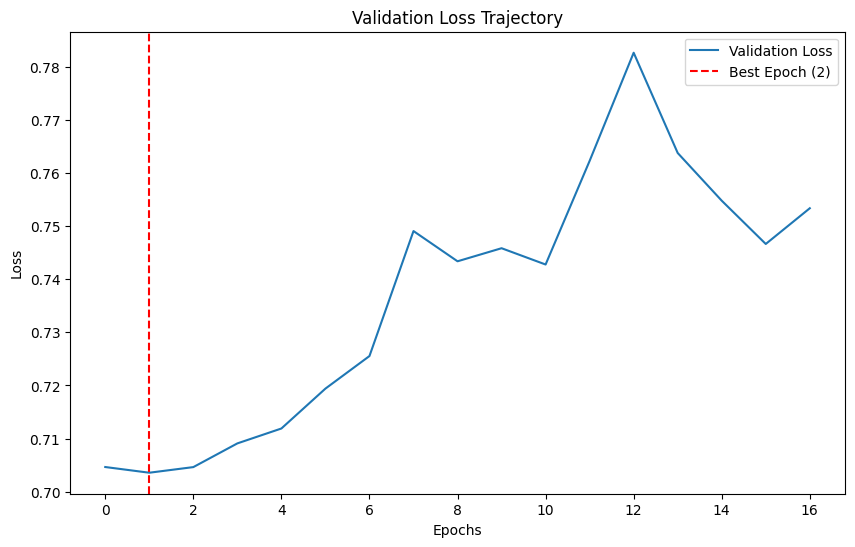

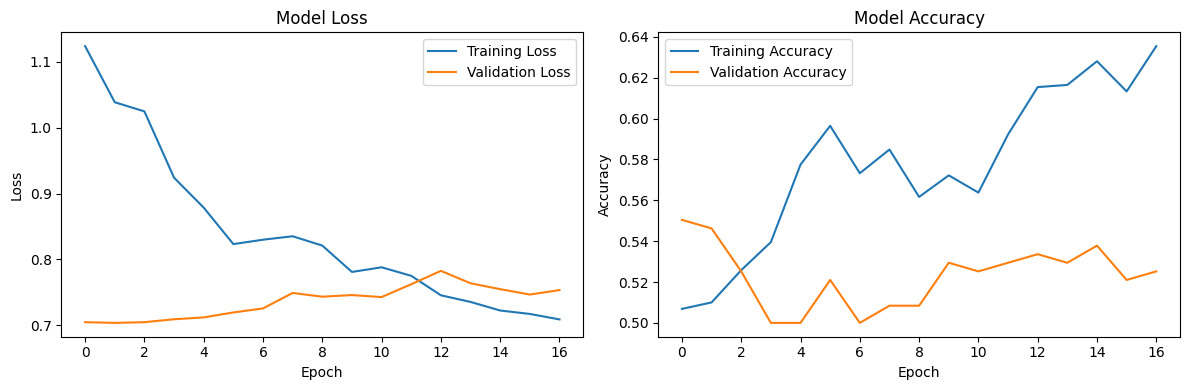


Final evaluation:
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5209 - auc: 0.5174 - loss: 0.7094 - precision: 0.4802 - recall: 0.5570
Metrics Dictionary: {'loss': 0.7090701460838318, 'compile_metrics': 0.5185185074806213}
Manually calculated accuracy: 0.5185

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.52      0.52       149
           1       0.52      0.52      0.52       148

    accuracy                           0.52       297
   macro avg       0.52      0.52      0.52       297
weighted avg       0.52      0.52      0.52       297


Test Metrics Summary:
Test loss: 0.7091
Test compile_metrics: 0.5185
Test accuracy: 0.5185


In [17]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
# from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(75, 6), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""            
        if self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
        
        elif self.model_type=="model-3":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            x = layers.Conv1D(128 * 2, kernel_size=3, padding="same", activation="relu")(x)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            # BiLSTM
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
            x = layers.BatchNormalization()(x)

            # Dense layers
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.5)(x)

            outputs = layers.Dense(1, activation="sigmoid")(x)

            model = models.Model(inputs, outputs)
    
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,weight_decay=1e-4),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=75, d_model=6):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 450:  # Verify input dimensions
            X = X.reshape(-1, 75, 6)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 6))
        X_train = self.scaler.transform(X_train.reshape(-1, 6)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 6)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-3', input_shape=(75, 6))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","eyeblink_dataset-Face2Face.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 75, 6)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_34 (Conv1D)              │ (None, 75, 128)        │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 75, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_27 (MaxPooling1D) │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_35 (Conv1D)              │ (None, 37, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 37, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_28 (MaxPooling1D) │ (None, 18, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_11                │ (None, 256)            │       394,240 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_46          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,353 (2.03 MB)

 Trainable params: 531,073 (2.03 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/100
14/14 - 5s - 331ms/step - accuracy: 0.5451 - auc: 0.5351 - loss: 1.1604 - precision: 0.4798 - recall: 0.2823 - val_accuracy: 0.4813 - val_auc: 0.4256 - val_loss: 0.7213 - val_precision: 0.3974 - val_recall: 0.3263
Epoch 2/100
14/14 - 1s - 63ms/step - accuracy: 0.5369 - auc: 0.5285 - loss: 1.0152 - precision: 0.4777 - recall: 0.4512 - val_accuracy: 0.4860 - val_auc: 0.5154 - val_loss: 0.7196 - val_precision: 0.4497 - val_recall: 0.7053
Epoch 3/100
14/14 - 1s - 87ms/step - accuracy: 0.5311 - auc: 0.5491 - loss: 0.9600 - precision: 0.4723 - recall: 0.4723 - val_accuracy: 0.4953 - val_auc: 0.4993 - val_loss: 0.7132 - val_precision: 0.4526 - val_recall: 0.6526
Epoch 4/100
14/14 - 1s - 73ms/step - accuracy: 0.5967 - auc: 0.6195 - loss: 0.8495 - precision: 0.5516 - recall: 0.4934 - val_accuracy: 0.5140 - val_auc: 0.5085 - val_loss: 0.7164 - val_precision: 0.4702 - val_recall: 0.7474
Epoch 5/100
14/14 - 1s - 68ms/step - accuracy: 0.5733 - auc: 0.6012 - loss: 0.8641 - precision: 0.5

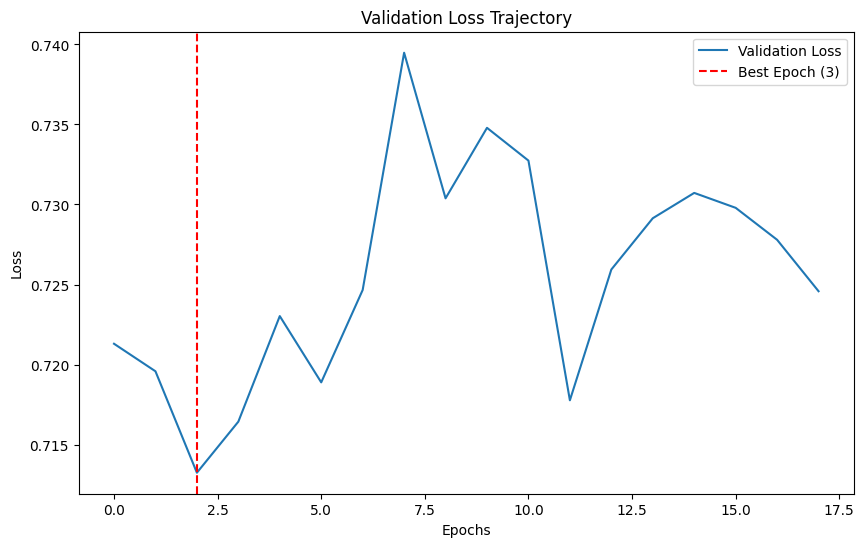

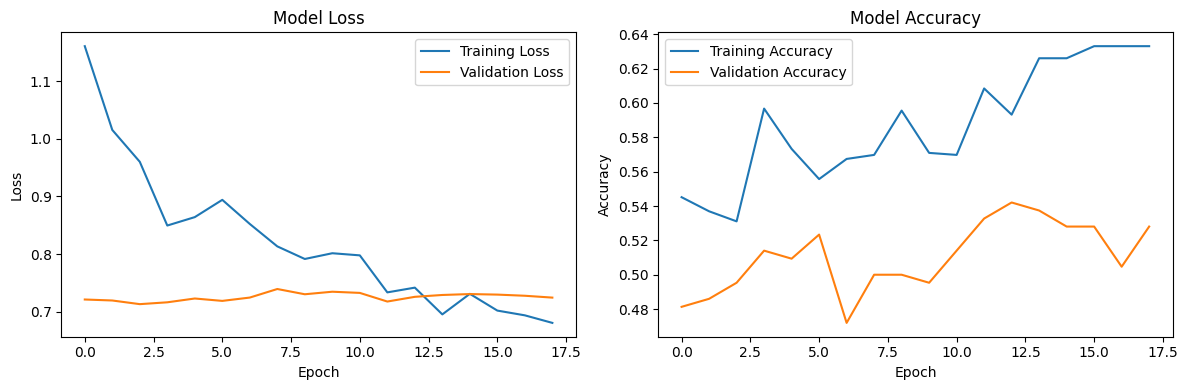


Final evaluation:
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4808 - auc: 0.4654 - loss: 0.7202 - precision: 0.4294 - recall: 0.6741
Metrics Dictionary: {'loss': 0.7201856970787048, 'compile_metrics': 0.4681648015975952}
Manually calculated accuracy: 0.4682

Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.33      0.41       149
           1       0.43      0.64      0.52       118

    accuracy                           0.47       267
   macro avg       0.49      0.49      0.46       267
weighted avg       0.49      0.47      0.46       267


Test Metrics Summary:
Test loss: 0.7202
Test compile_metrics: 0.4682
Test accuracy: 0.4682


In [18]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
# from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(75, 6), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""            
        if self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
        
        elif self.model_type=="model-3":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            x = layers.Conv1D(128 * 2, kernel_size=3, padding="same", activation="relu")(x)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            # BiLSTM
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
            x = layers.BatchNormalization()(x)

            # Dense layers
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.5)(x)

            outputs = layers.Dense(1, activation="sigmoid")(x)

            model = models.Model(inputs, outputs)
    
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,weight_decay=1e-4),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=75, d_model=6):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 450:  # Verify input dimensions
            X = X.reshape(-1, 75, 6)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 6))
        X_train = self.scaler.transform(X_train.reshape(-1, 6)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 6)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-3', input_shape=(75, 6))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","eyeblink_dataset-FaceSwap.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 56, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_36 (Conv1D)              │ (None, 56, 128)        │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 56, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_29 (MaxPooling1D) │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_37 (Conv1D)              │ (None, 28, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 28, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_30 (MaxPooling1D) │ (None, 14, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_12                │ (None, 256)            │       394,240 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_49          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,993 (2.03 MB)

 Trainable params: 531,713 (2.03 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/100
23/23 - 5s - 206ms/step - accuracy: 0.5366 - auc: 0.5540 - loss: 1.0686 - precision: 0.5423 - recall: 0.4696 - val_accuracy: 0.6309 - val_auc: 0.6516 - val_loss: 0.6918 - val_precision: 0.6121 - val_recall: 0.7198
Epoch 2/100
23/23 - 1s - 38ms/step - accuracy: 0.5718 - auc: 0.5830 - loss: 0.9718 - precision: 0.5716 - recall: 0.5732 - val_accuracy: 0.6143 - val_auc: 0.6863 - val_loss: 0.6875 - val_precision: 0.5734 - val_recall: 0.9011
Epoch 3/100
23/23 - 1s - 35ms/step - accuracy: 0.5566 - auc: 0.5831 - loss: 0.9311 - precision: 0.5592 - recall: 0.5345 - val_accuracy: 0.6116 - val_auc: 0.6567 - val_loss: 0.6946 - val_precision: 0.5668 - val_recall: 0.9560
Epoch 4/100
23/23 - 1s - 38ms/step - accuracy: 0.5773 - auc: 0.6079 - loss: 0.8592 - precision: 0.5805 - recall: 0.5580 - val_accuracy: 0.6226 - val_auc: 0.6745 - val_loss: 0.6780 - val_precision: 0.5812 - val_recall: 0.8846
Epoch 5/100
23/23 - 1s - 39ms/step - accuracy: 0.5691 - auc: 0.6064 - loss: 0.8349 - precision: 0.5

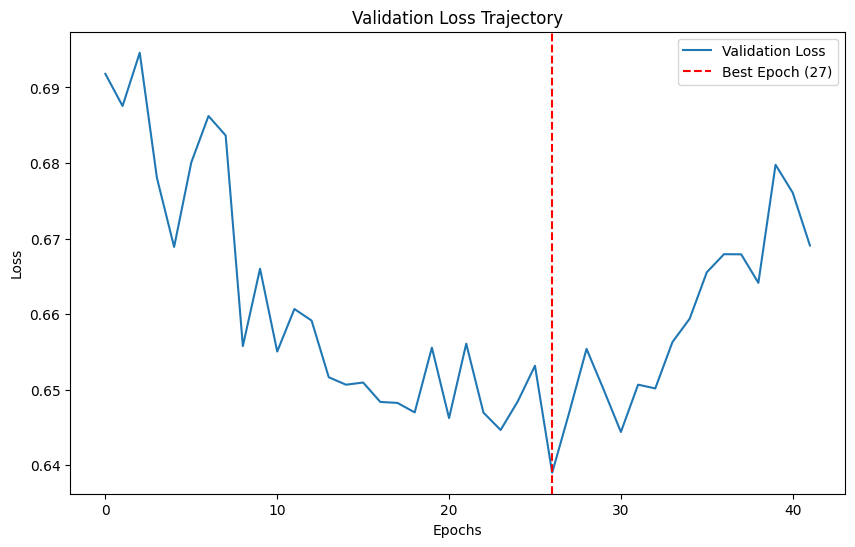

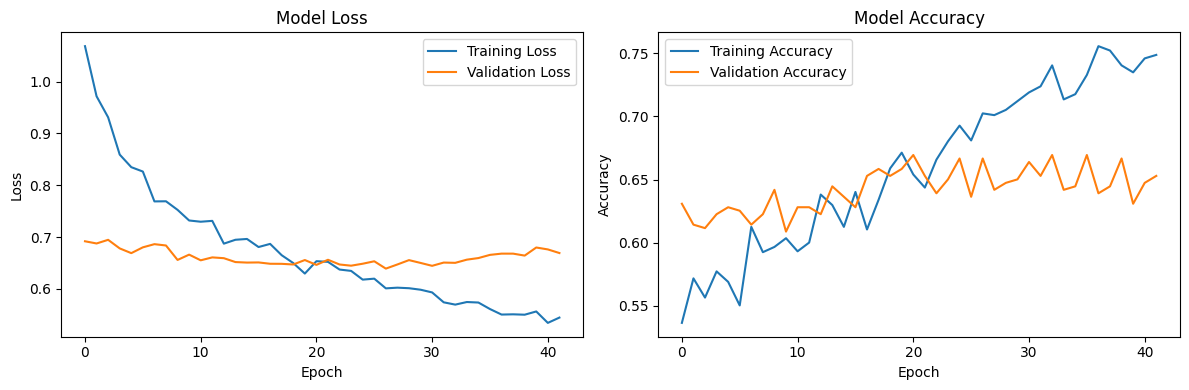


Final evaluation:
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6388 - auc: 0.7070 - loss: 0.6536 - precision: 0.6076 - recall: 0.7827
Metrics Dictionary: {'loss': 0.6534366607666016, 'compile_metrics': 0.6379690766334534}
Manually calculated accuracy: 0.6380

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.50      0.58       227
           1       0.61      0.77      0.68       226

    accuracy                           0.64       453
   macro avg       0.65      0.64      0.63       453
weighted avg       0.65      0.64      0.63       453


Test Metrics Summary:
Test loss: 0.6534
Test compile_metrics: 0.6380
Test accuracy: 0.6380


In [19]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""            
        if self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
        
        elif self.model_type=="model-3":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            x = layers.Conv1D(128 * 2, kernel_size=3, padding="same", activation="relu")(x)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            # BiLSTM
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
            x = layers.BatchNormalization()(x)

            # Dense layers
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.5)(x)

            outputs = layers.Dense(1, activation="sigmoid")(x)

            model = models.Model(inputs, outputs)
    
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,weight_decay=1e-4),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-3', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-deepfake_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 56, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_38 (Conv1D)              │ (None, 56, 128)        │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_50          │ (None, 56, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_31 (MaxPooling1D) │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_39 (Conv1D)              │ (None, 28, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_51          │ (None, 28, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_32 (MaxPooling1D) │ (None, 14, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_13                │ (None, 256)            │       394,240 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,993 (2.03 MB)

 Trainable params: 531,713 (2.03 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/100
27/27 - 5s - 195ms/step - accuracy: 0.5732 - auc: 0.5770 - loss: 0.9899 - precision: 0.6150 - recall: 0.6536 - val_accuracy: 0.6571 - val_auc: 0.6944 - val_loss: 0.6853 - val_precision: 0.7085 - val_recall: 0.6695
Epoch 2/100
27/27 - 1s - 38ms/step - accuracy: 0.5810 - auc: 0.6215 - loss: 0.8846 - precision: 0.6316 - recall: 0.6196 - val_accuracy: 0.5731 - val_auc: 0.6372 - val_loss: 0.6848 - val_precision: 0.6576 - val_recall: 0.5127
Epoch 3/100
27/27 - 1s - 45ms/step - accuracy: 0.6020 - auc: 0.6290 - loss: 0.8240 - precision: 0.6485 - recall: 0.6451 - val_accuracy: 0.6331 - val_auc: 0.6912 - val_loss: 0.6611 - val_precision: 0.6751 - val_recall: 0.6780
Epoch 4/100
27/27 - 2s - 61ms/step - accuracy: 0.6194 - auc: 0.6560 - loss: 0.7969 - precision: 0.6594 - recall: 0.6748 - val_accuracy: 0.6355 - val_auc: 0.6978 - val_loss: 0.6670 - val_precision: 0.7763 - val_recall: 0.5000
Epoch 5/100
27/27 - 2s - 67ms/step - accuracy: 0.5924 - auc: 0.6331 - loss: 0.7909 - precision: 0.6

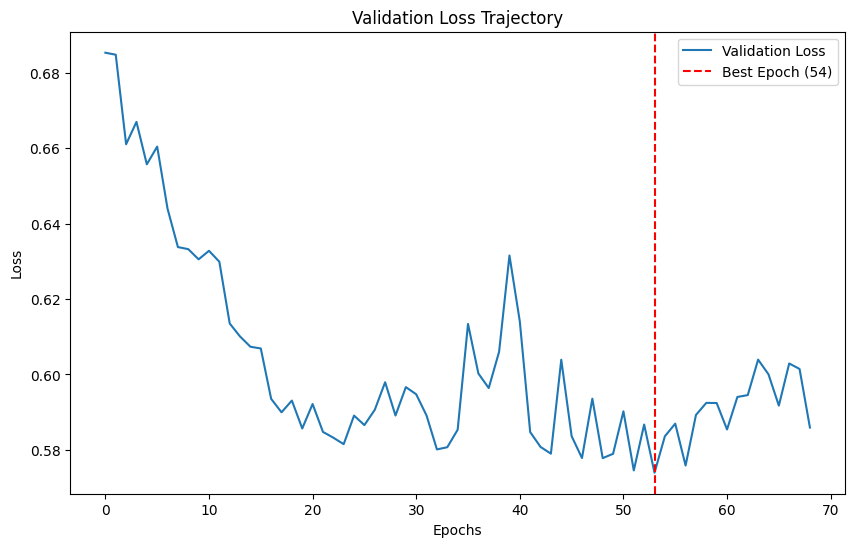

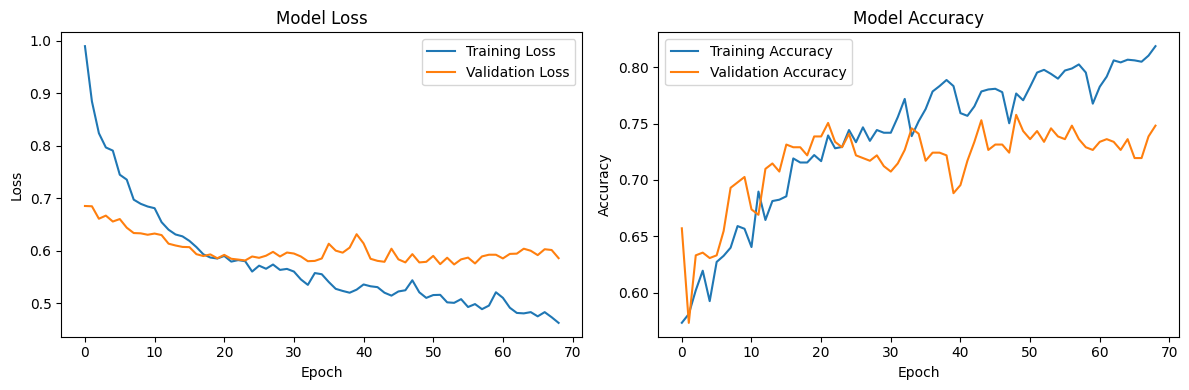


Final evaluation:
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7604 - auc: 0.8100 - loss: 0.5911 - precision: 0.8100 - recall: 0.7497
Metrics Dictionary: {'loss': 0.5834383964538574, 'compile_metrics': 0.7639155387878418}
Manually calculated accuracy: 0.7639

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.79      0.74       226
           1       0.82      0.74      0.78       295

    accuracy                           0.76       521
   macro avg       0.76      0.77      0.76       521
weighted avg       0.77      0.76      0.76       521


Test Metrics Summary:
Test loss: 0.5834
Test compile_metrics: 0.7639
Test accuracy: 0.7639


In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""            
        if self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
        
        elif self.model_type=="model-3":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            x = layers.Conv1D(128 * 2, kernel_size=3, padding="same", activation="relu")(x)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            # BiLSTM
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
            x = layers.BatchNormalization()(x)

            # Dense layers
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.5)(x)

            outputs = layers.Dense(1, activation="sigmoid")(x)

            model = models.Model(inputs, outputs)
        
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,weight_decay=1e-4),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-3', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-DeepFakeDetection_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 56, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_40 (Conv1D)              │ (None, 56, 128)        │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 56, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_33 (MaxPooling1D) │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_41 (Conv1D)              │ (None, 28, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 28, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_34 (MaxPooling1D) │ (None, 14, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_14                │ (None, 256)            │       394,240 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,993 (2.03 MB)

 Trainable params: 531,713 (2.03 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/100
23/23 - 5s - 237ms/step - accuracy: 0.4696 - auc: 0.4624 - loss: 1.1259 - precision: 0.4704 - recall: 0.4820 - val_accuracy: 0.4986 - val_auc: 0.4823 - val_loss: 0.7167 - val_precision: 0.5000 - val_recall: 0.0385
Epoch 2/100
23/23 - 1s - 41ms/step - accuracy: 0.5097 - auc: 0.5175 - loss: 0.9478 - precision: 0.5094 - recall: 0.5235 - val_accuracy: 0.4959 - val_auc: 0.5946 - val_loss: 0.7120 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/100
23/23 - 1s - 39ms/step - accuracy: 0.5152 - auc: 0.5156 - loss: 0.9007 - precision: 0.5159 - recall: 0.4945 - val_accuracy: 0.4931 - val_auc: 0.5558 - val_loss: 0.7125 - val_precision: 0.2500 - val_recall: 0.0055
Epoch 4/100
23/23 - 1s - 41ms/step - accuracy: 0.5442 - auc: 0.5437 - loss: 0.8519 - precision: 0.5427 - recall: 0.5622 - val_accuracy: 0.4986 - val_auc: 0.5720 - val_loss: 0.7077 - val_precision: 0.5000 - val_recall: 0.0549
Epoch 5/100
23/23 - 1s - 41ms/step - accuracy: 0.5394 - auc: 0.5550 - loss: 0.8271 - precis

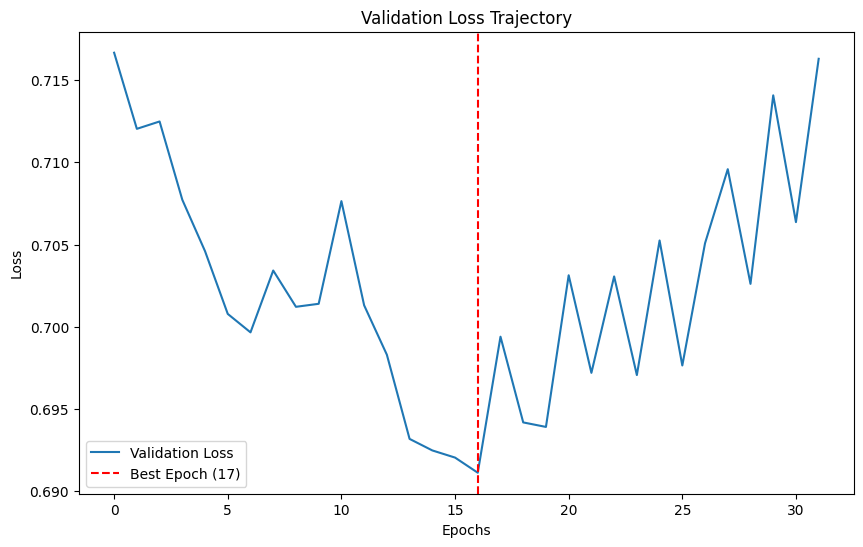

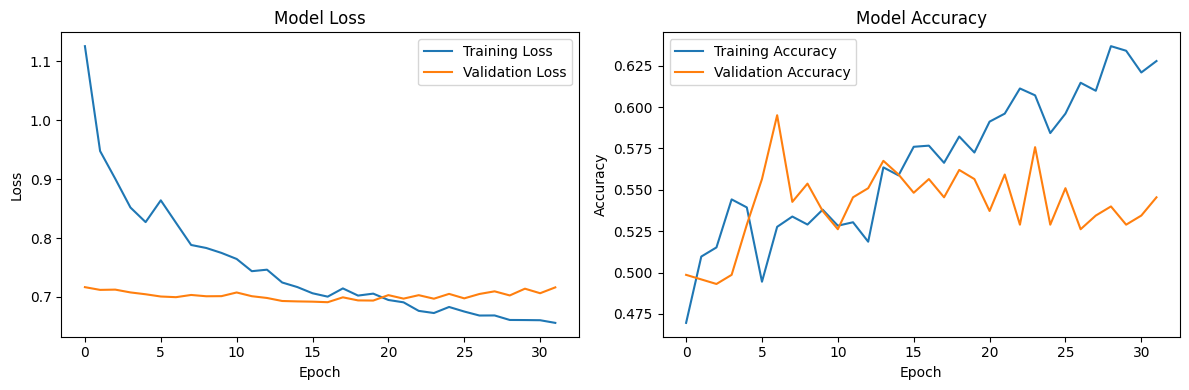


Final evaluation:
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5545 - auc: 0.5778 - loss: 0.6946 - precision: 0.5443 - recall: 0.6534
Metrics Dictionary: {'loss': 0.6942929625511169, 'compile_metrics': 0.5496688485145569}
Manually calculated accuracy: 0.5497

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.43      0.49       227
           1       0.54      0.67      0.60       226

    accuracy                           0.55       453
   macro avg       0.55      0.55      0.54       453
weighted avg       0.55      0.55      0.54       453


Test Metrics Summary:
Test loss: 0.6943
Test compile_metrics: 0.5497
Test accuracy: 0.5497


In [21]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""            
        if self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
        
        elif self.model_type=="model-3":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            x = layers.Conv1D(128 * 2, kernel_size=3, padding="same", activation="relu")(x)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            # BiLSTM
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
            x = layers.BatchNormalization()(x)

            # Dense layers
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.5)(x)

            outputs = layers.Dense(1, activation="sigmoid")(x)

            model = models.Model(inputs, outputs)
    
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,weight_decay=1e-4),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-3', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-Face2Face_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 56, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_42 (Conv1D)              │ (None, 56, 128)        │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_56          │ (None, 56, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_35 (MaxPooling1D) │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_43 (Conv1D)              │ (None, 28, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_57          │ (None, 28, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_36 (MaxPooling1D) │ (None, 14, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_15                │ (None, 256)            │       394,240 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_58          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_42 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_43 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 532,993 (2.03 MB)

 Trainable params: 531,713 (2.03 MB)

 Non-trainable params: 1,280 (5.00 KB)

Epoch 1/100
21/21 - 5s - 217ms/step - accuracy: 0.5030 - auc: 0.5013 - loss: 1.0588 - precision: 0.4517 - recall: 0.5085 - val_accuracy: 0.5471 - val_auc: 0.6215 - val_loss: 0.6939 - val_precision: 0.4921 - val_recall: 0.2095
Epoch 2/100
21/21 - 1s - 38ms/step - accuracy: 0.5183 - auc: 0.5320 - loss: 0.9461 - precision: 0.4628 - recall: 0.4660 - val_accuracy: 0.5380 - val_auc: 0.6243 - val_loss: 0.6993 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/100
21/21 - 1s - 41ms/step - accuracy: 0.5427 - auc: 0.5427 - loss: 0.9002 - precision: 0.4895 - recall: 0.4762 - val_accuracy: 0.5532 - val_auc: 0.5048 - val_loss: 0.7075 - val_precision: 0.5333 - val_recall: 0.0541
Epoch 4/100
21/21 - 1s - 61ms/step - accuracy: 0.5434 - auc: 0.5641 - loss: 0.8414 - precision: 0.4904 - recall: 0.4762 - val_accuracy: 0.4742 - val_auc: 0.4222 - val_loss: 0.7189 - val_precision: 0.2449 - val_recall: 0.0811
Epoch 5/100
21/21 - 1s - 58ms/step - accuracy: 0.5511 - auc: 0.5535 - loss: 0.8298 - precis

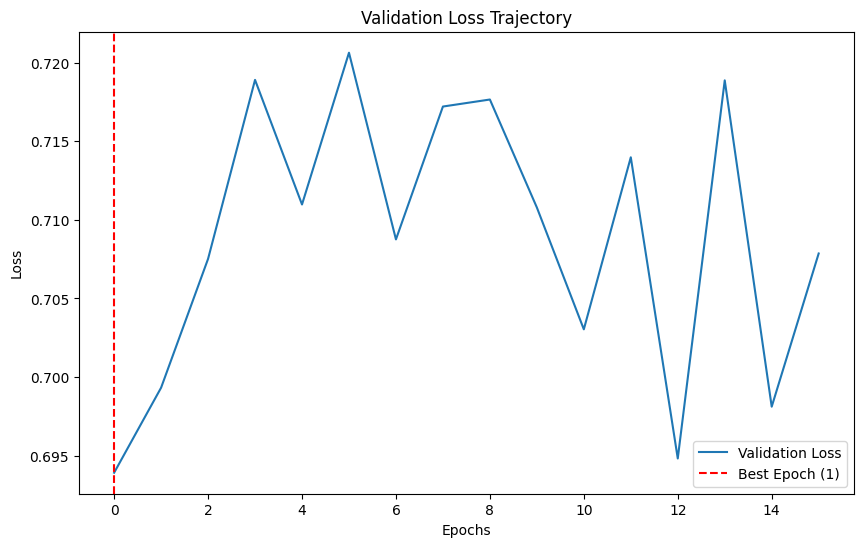

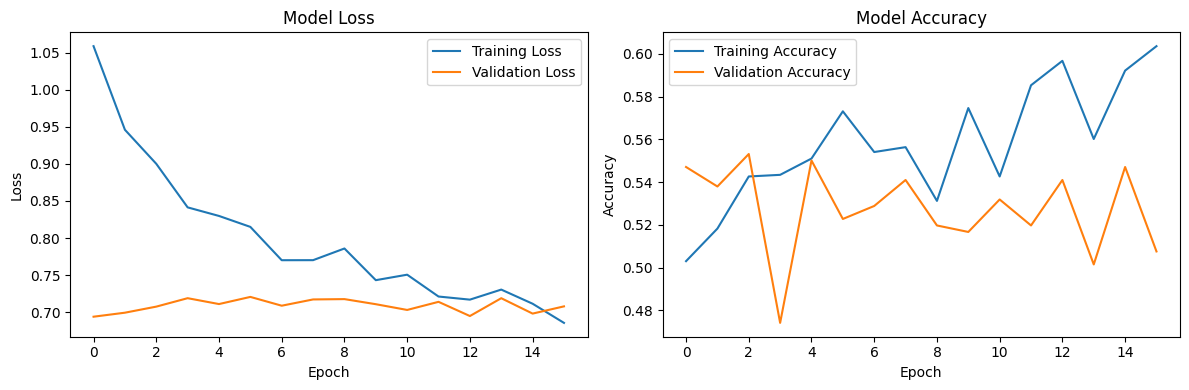


Final evaluation:
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5416 - auc: 0.5902 - loss: 0.7011 - precision: 0.5235 - recall: 0.2447
Metrics Dictionary: {'loss': 0.7018438577651978, 'compile_metrics': 0.5523114204406738}
Manually calculated accuracy: 0.5523

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.80      0.66       227
           1       0.50      0.24      0.33       184

    accuracy                           0.55       411
   macro avg       0.53      0.52      0.50       411
weighted avg       0.54      0.55      0.51       411


Test Metrics Summary:
Test loss: 0.7018
Test compile_metrics: 0.5523
Test accuracy: 0.5523


In [22]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""            
        if self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
        
        elif self.model_type=="model-3":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            x = layers.Conv1D(128 * 2, kernel_size=3, padding="same", activation="relu")(x)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            # BiLSTM
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
            x = layers.BatchNormalization()(x)

            # Dense layers
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.5)(x)

            outputs = layers.Dense(1, activation="sigmoid")(x)

            model = models.Model(inputs, outputs)
    
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,weight_decay=1e-4),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-3', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-FaceSwap_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


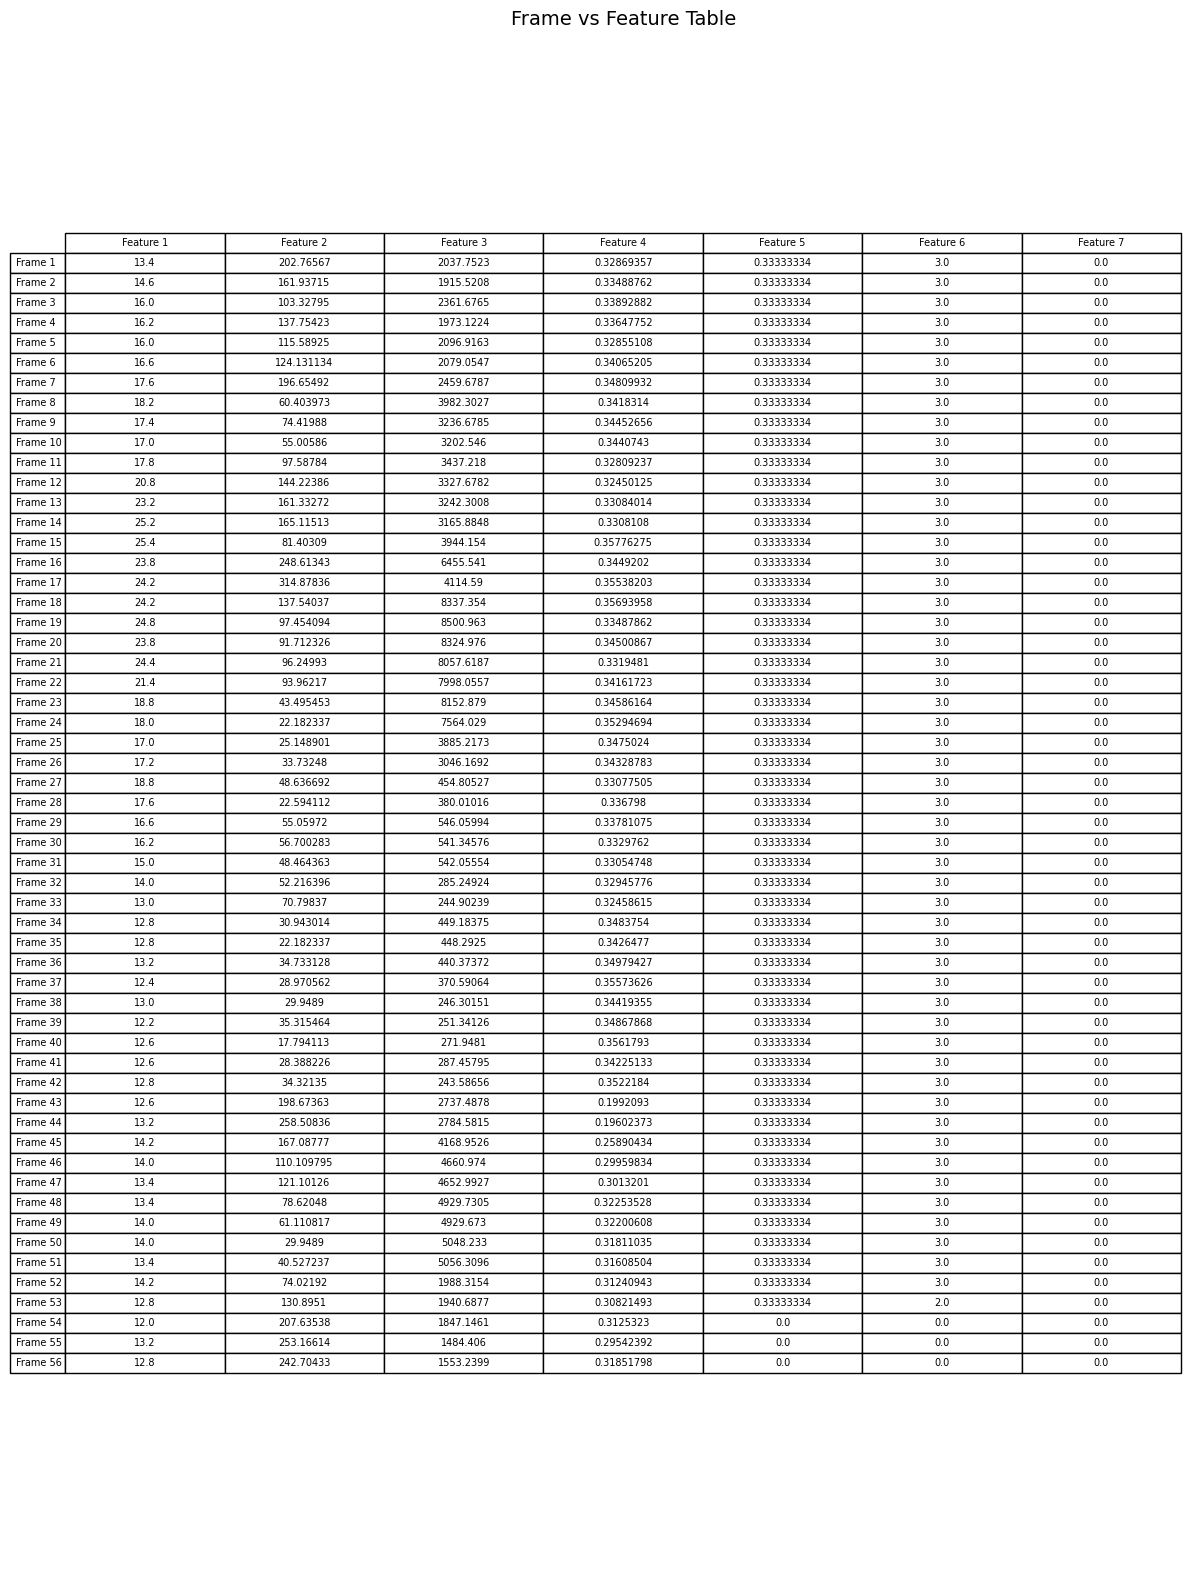

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Input data (flattened list of 56*7 = 392 values)
data = [
    13.4,202.76567,2037.7523,0.32869357,0.33333334,3.0,0.0,
    14.6,161.93715,1915.5208,0.33488762,0.33333334,3.0,0.0,
    16.0,103.32795,2361.6765,0.33892882,0.33333334,3.0,0.0,
    16.2,137.75423,1973.1224,0.33647752,0.33333334,3.0,0.0,
    16.0,115.58925,2096.9163,0.32855108,0.33333334,3.0,0.0,
    16.6,124.131134,2079.0547,0.34065205,0.33333334,3.0,0.0,
    17.6,196.65492,2459.6787,0.34809932,0.33333334,3.0,0.0,
    18.2,60.403973,3982.3027,0.3418314,0.33333334,3.0,0.0,
    17.4,74.41988,3236.6785,0.34452656,0.33333334,3.0,0.0,
    17.0,55.00586,3202.546,0.3440743,0.33333334,3.0,0.0,
    17.8,97.58784,3437.218,0.32809237,0.33333334,3.0,0.0,
    20.8,144.22386,3327.6782,0.32450125,0.33333334,3.0,0.0,
    23.2,161.33272,3242.3008,0.33084014,0.33333334,3.0,0.0,
    25.2,165.11513,3165.8848,0.3308108,0.33333334,3.0,0.0,
    25.4,81.40309,3944.154,0.35776275,0.33333334,3.0,0.0,
    23.8,248.61343,6455.541,0.3449202,0.33333334,3.0,0.0,
    24.2,314.87836,4114.59,0.35538203,0.33333334,3.0,0.0,
    24.2,137.54037,8337.354,0.35693958,0.33333334,3.0,0.0,
    24.8,97.454094,8500.963,0.33487862,0.33333334,3.0,0.0,
    23.8,91.712326,8324.976,0.34500867,0.33333334,3.0,0.0,
    24.4,96.24993,8057.6187,0.3319481,0.33333334,3.0,0.0,
    21.4,93.96217,7998.0557,0.34161723,0.33333334,3.0,0.0,
    18.8,43.495453,8152.879,0.34586164,0.33333334,3.0,0.0,
    18.0,22.182337,7564.029,0.35294694,0.33333334,3.0,0.0,
    17.0,25.148901,3885.2173,0.3475024,0.33333334,3.0,0.0,
    17.2,33.73248,3046.1692,0.34328783,0.33333334,3.0,0.0,
    18.8,48.636692,454.80527,0.33077505,0.33333334,3.0,0.0,
    17.6,22.594112,380.01016,0.336798,0.33333334,3.0,0.0,
    16.6,55.05972,546.05994,0.33781075,0.33333334,3.0,0.0,
    16.2,56.700283,541.34576,0.3329762,0.33333334,3.0,0.0,
    15.0,48.464363,542.05554,0.33054748,0.33333334,3.0,0.0,
    14.0,52.216396,285.24924,0.32945776,0.33333334,3.0,0.0,
    13.0,70.79837,244.90239,0.32458615,0.33333334,3.0,0.0,
    12.8,30.943014,449.18375,0.3483754,0.33333334,3.0,0.0,
    12.8,22.182337,448.2925,0.3426477,0.33333334,3.0,0.0,
    13.2,34.733128,440.37372,0.34979427,0.33333334,3.0,0.0,
    12.4,28.970562,370.59064,0.35573626,0.33333334,3.0,0.0,
    13.0,29.9489,246.30151,0.34419355,0.33333334,3.0,0.0,
    12.2,35.315464,251.34126,0.34867868,0.33333334,3.0,0.0,
    12.6,17.794113,271.9481,0.3561793,0.33333334,3.0,0.0,
    12.6,28.388226,287.45795,0.34225133,0.33333334,3.0,0.0,
    12.8,34.32135,243.58656,0.3522184,0.33333334,3.0,0.0,
    12.6,198.67363,2737.4878,0.1992093,0.33333334,3.0,0.0,
    13.2,258.50836,2784.5815,0.19602373,0.33333334,3.0,0.0,
    14.2,167.08777,4168.9526,0.25890434,0.33333334,3.0,0.0,
    14.0,110.109795,4660.974,0.29959834,0.33333334,3.0,0.0,
    13.4,121.10126,4652.9927,0.3013201,0.33333334,3.0,0.0,
    13.4,78.62048,4929.7305,0.32253528,0.33333334,3.0,0.0,
    14.0,61.110817,4929.673,0.32200608,0.33333334,3.0,0.0,
    14.0,29.9489,5048.233,0.31811035,0.33333334,3.0,0.0,
    13.4,40.527237,5056.3096,0.31608504,0.33333334,3.0,0.0,
    14.2,74.02192,1988.3154,0.31240943,0.33333334,3.0,0.0,
    12.8,130.8951,1940.6877,0.30821493,0.33333334,2.0,0.0,
    12.0,207.63538,1847.1461,0.3125323,0.0,0.0,0.0,
    13.2,253.16614,1484.406,0.29542392,0.0,0.0,0.0,
    12.8,242.70433,1553.2399,0.31851798,0.0,0.0,0.0
]

# Reshape into 56 rows × 7 columns
array = np.array(data).reshape(56, 7)

# Create DataFrame
df = pd.DataFrame(array, columns=[f"Feature {i+1}" for i in range(7)],
                         index=[f"Frame {i+1}" for i in range(56)])

# Plot table
fig, ax = plt.subplots(figsize=(12, 20))
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=df.values, colLabels=df.columns, rowLabels=df.index,
                 cellLoc='center', loc='center')

table.auto_set_font_size(False)
table.set_fontsize(7)
table.scale(1.2, 1.2)

plt.title("Frame vs Feature Table", fontsize=14)
plt.show()


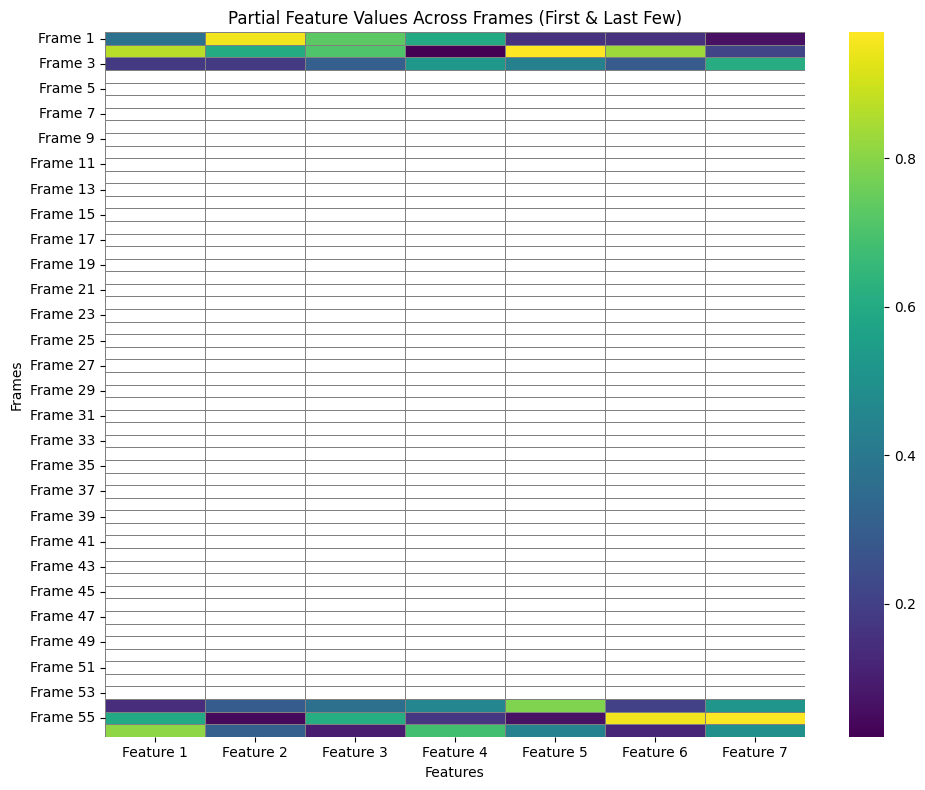

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Create an empty DataFrame with NaNs
data = np.full((56, 7), np.nan)

# Fill in values for the first 3 and last 3 frames
np.random.seed(42)
data[:3] = np.random.rand(3, 7)
data[-3:] = np.random.rand(3, 7)

# Create DataFrame
df = pd.DataFrame(data, columns=[
    'Feature 1', 'Feature 2', 'Feature 3',
    'Feature 4', 'Feature 5', 'Feature 6', 'Feature 7'
], index=[f'Frame {i+1}' for i in range(56)])

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df, cmap='viridis', cbar=True, mask=df.isna(), linewidths=0.5, linecolor='gray')
plt.title('Partial Feature Values Across Frames (First & Last Few)')
plt.xlabel('Features')
plt.ylabel('Frames')
plt.tight_layout()
plt.show()


Model architecture:


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 56, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 56, 256)        │       139,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 56, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 56, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 577,537 (2.20 MB)

 Trainable params: 576,129 (2.20 MB)

 Non-trainable params: 1,408 (5.50 KB)

Epoch 1/100
27/27 - 17s - 616ms/step - accuracy: 0.5390 - auc: 0.5532 - loss: 0.9465 - precision: 0.6021 - recall: 0.5420 - val_accuracy: 0.6163 - val_auc: 0.6775 - val_loss: 0.6935 - val_precision: 0.6152 - val_recall: 0.8602
Epoch 2/100
27/27 - 6s - 239ms/step - accuracy: 0.5822 - auc: 0.6179 - loss: 0.8198 - precision: 0.6390 - recall: 0.5983 - val_accuracy: 0.6259 - val_auc: 0.6800 - val_loss: 0.6818 - val_precision: 0.6460 - val_recall: 0.7500
Epoch 3/100
27/27 - 10s - 381ms/step - accuracy: 0.5906 - auc: 0.6120 - loss: 0.8044 - precision: 0.6376 - recall: 0.6376 - val_accuracy: 0.5923 - val_auc: 0.6592 - val_loss: 0.6805 - val_precision: 0.5965 - val_recall: 0.8644
Epoch 4/100
27/27 - 10s - 374ms/step - accuracy: 0.5810 - auc: 0.6176 - loss: 0.7937 - precision: 0.6254 - recall: 0.6440 - val_accuracy: 0.6043 - val_auc: 0.6580 - val_loss: 0.6797 - val_precision: 0.6141 - val_recall: 0.8093
Epoch 5/100
27/27 - 10s - 375ms/step - accuracy: 0.6056 - auc: 0.6348 - loss: 0.7573 - precis

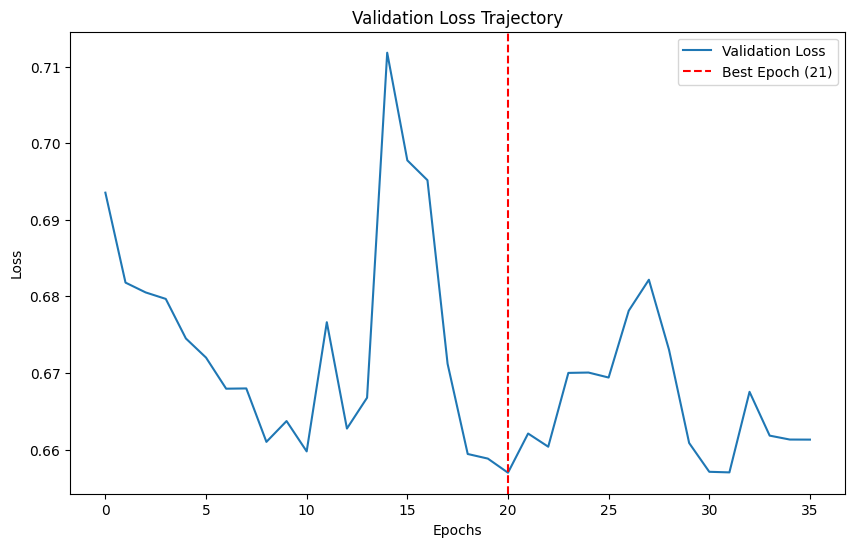

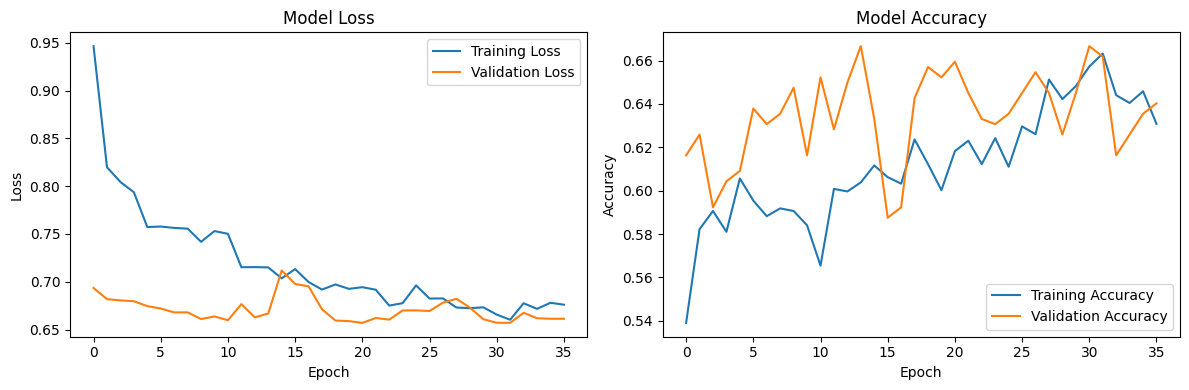


Final evaluation:
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.6812 - auc: 0.7313 - loss: 0.6488 - precision: 0.7168 - recall: 0.7136
Metrics Dictionary: {'loss': 0.6504262089729309, 'compile_metrics': 0.6756237745285034}
Manually calculated accuracy: 0.6756

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.64      0.63       226
           1       0.72      0.70      0.71       295

    accuracy                           0.68       521
   macro avg       0.67      0.67      0.67       521
weighted avg       0.68      0.68      0.68       521


Test Metrics Summary:
Test loss: 0.6504
Test compile_metrics: 0.6756
Test accuracy: 0.6756


In [3]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""            
        if self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
        
        elif self.model_type=="model-3":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            x = layers.Conv1D(128 * 2, kernel_size=3, padding="same", activation="relu")(x)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            # BiLSTM
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
            x = layers.BatchNormalization()(x)

            # Dense layers
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.5)(x)

            outputs = layers.Dense(1, activation="sigmoid")(x)

            model = models.Model(inputs, outputs)
        
        elif self.model_type=="model-4":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            # --- BiLSTM ---
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.Dropout(0.5)(x)

            x = layers.Bidirectional(layers.LSTM(128))(x)
            x = layers.BatchNormalization()(x)
            x = layers.Dropout(0.4)(x)

            # --- ANN Head ---
            for units in [128,64]:
                x = layers.Dense(units, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
                x = layers.BatchNormalization()(x)
                x = layers.Dropout(0.4)(x)

            outputs = layers.Dense(1, activation='sigmoid')(x)

            model = models.Model(inputs, outputs)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,weight_decay=1e-4),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-4', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-DeepFakeDetection_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ (None, 56, 128)        │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 56, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,905 (312.13 KB)

 Trainable params: 79,521 (310.63 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
27/27 - 12s - 449ms/step - accuracy: 0.5726 - auc: 0.5913 - loss: 0.7352 - precision: 0.6174 - recall: 0.6397 - val_accuracy: 0.5827 - val_auc: 0.6564 - val_loss: 0.6825 - val_precision: 0.6566 - val_recall: 0.5508
Epoch 2/100
27/27 - 2s - 78ms/step - accuracy: 0.5996 - auc: 0.6240 - loss: 0.6893 - precision: 0.6288 - recall: 0.7109 - val_accuracy: 0.6019 - val_auc: 0.6561 - val_loss: 0.6765 - val_precision: 0.6483 - val_recall: 0.6483
Epoch 3/100
27/27 - 4s - 154ms/step - accuracy: 0.6140 - auc: 0.6569 - loss: 0.6661 - precision: 0.6533 - recall: 0.6748 - val_accuracy: 0.6043 - val_auc: 0.6710 - val_loss: 0.6710 - val_precision: 0.6983 - val_recall: 0.5297
Epoch 4/100
27/27 - 5s - 188ms/step - accuracy: 0.6327 - auc: 0.6754 - loss: 0.6511 - precision: 0.6667 - recall: 0.6993 - val_accuracy: 0.6139 - val_auc: 0.6602 - val_loss: 0.6630 - val_precision: 0.6667 - val_recall: 0.6356
Epoch 5/100
27/27 - 4s - 156ms/step - accuracy: 0.6513 - auc: 0.6972 - loss: 0.6410 - precision:

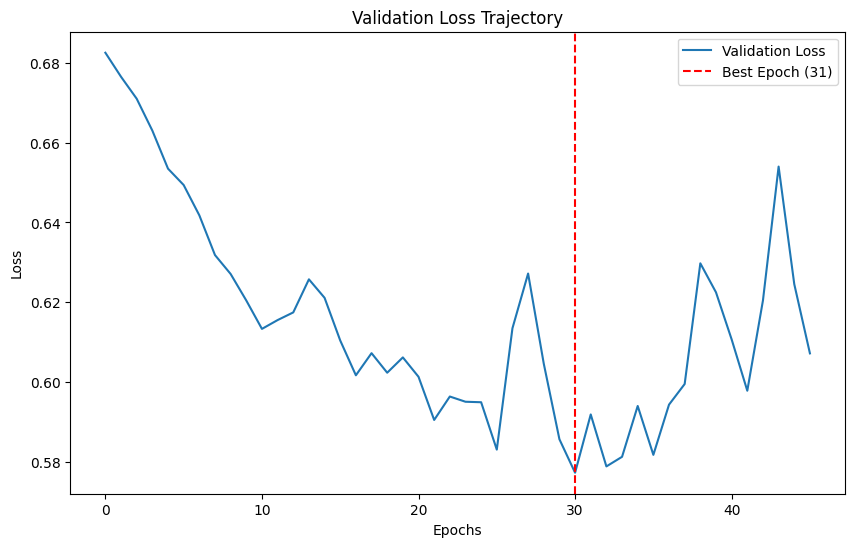

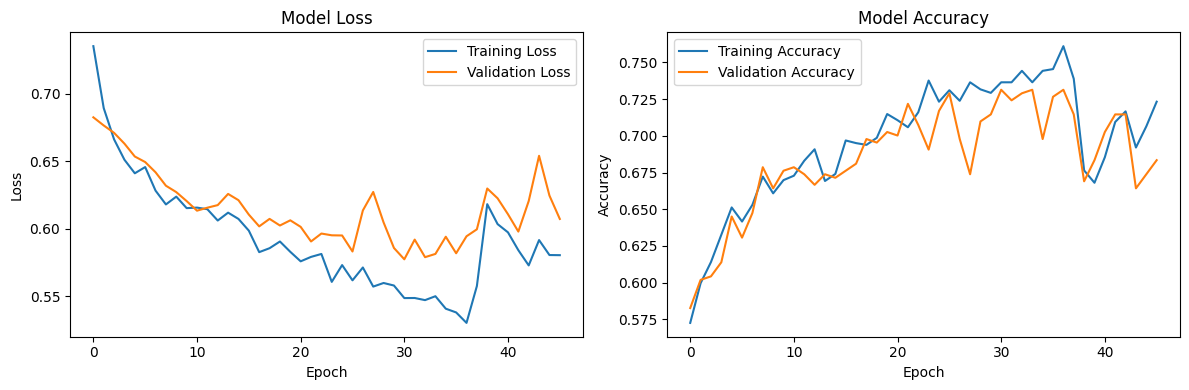


Final evaluation:
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.7348 - auc: 0.8005 - loss: 0.5757 - precision: 0.7964 - recall: 0.7098
Metrics Dictionary: {'loss': 0.5736263394355774, 'compile_metrics': 0.7332053780555725}
Manually calculated accuracy: 0.7332

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.77      0.71       226
           1       0.80      0.71      0.75       295

    accuracy                           0.73       521
   macro avg       0.73      0.74      0.73       521
weighted avg       0.74      0.73      0.73       521


Test Metrics Summary:
Test loss: 0.5736
Test compile_metrics: 0.7332
Test accuracy: 0.7332


In [5]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""            
        if self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
        elif self.model_type=="lstm":
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])

        elif self.model_type=="model-3":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            x = layers.Conv1D(128 * 2, kernel_size=3, padding="same", activation="relu")(x)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            # BiLSTM
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
            x = layers.BatchNormalization()(x)

            # Dense layers
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.5)(x)

            outputs = layers.Dense(1, activation="sigmoid")(x)

            model = models.Model(inputs, outputs)
        
        elif self.model_type=="model-4":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            # --- BiLSTM ---
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.Dropout(0.5)(x)

            x = layers.Bidirectional(layers.LSTM(128))(x)
            x = layers.BatchNormalization()(x)
            x = layers.Dropout(0.4)(x)

            # --- ANN Head ---
            for units in [128,64]:
                x = layers.Dense(units, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
                x = layers.BatchNormalization()(x)
                x = layers.Dropout(0.4)(x)

            outputs = layers.Dense(1, activation='sigmoid')(x)

            model = models.Model(inputs, outputs)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,weight_decay=1e-4),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='lstm', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-DeepFakeDetection_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')


Model architecture:


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 56, 7)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 56, 64)         │           512 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 56, 64)         │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 56, 64)         │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 56, 64)         │         4,160 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 56, 64)         │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 56, 64)         │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,833 (440.75 KB)

 Trainable params: 112,321 (438.75 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/100
27/27 - 48s - 2s/step - accuracy: 0.5612 - auc: 0.5853 - loss: 0.8371 - precision: 0.6164 - recall: 0.5909 - val_accuracy: 0.6235 - val_auc: 0.6679 - val_loss: 0.6807 - val_precision: 0.6787 - val_recall: 0.6356
Epoch 2/100
27/27 - 3s - 99ms/step - accuracy: 0.5780 - auc: 0.6023 - loss: 0.8004 - precision: 0.6266 - recall: 0.6259 - val_accuracy: 0.6043 - val_auc: 0.6516 - val_loss: 0.6812 - val_precision: 0.6498 - val_recall: 0.6525
Epoch 3/100
27/27 - 3s - 106ms/step - accuracy: 0.5708 - auc: 0.6024 - loss: 0.7817 - precision: 0.6180 - recall: 0.6291 - val_accuracy: 0.6043 - val_auc: 0.6486 - val_loss: 0.6741 - val_precision: 0.6120 - val_recall: 0.8220
Epoch 4/100
27/27 - 3s - 98ms/step - accuracy: 0.5876 - auc: 0.6219 - loss: 0.7432 - precision: 0.6320 - recall: 0.6461 - val_accuracy: 0.5971 - val_auc: 0.6734 - val_loss: 0.6745 - val_precision: 0.6889 - val_recall: 0.5254
Epoch 5/100
27/27 - 3s - 105ms/step - accuracy: 0.5840 - auc: 0.6208 - loss: 0.7272 - precision: 0.6

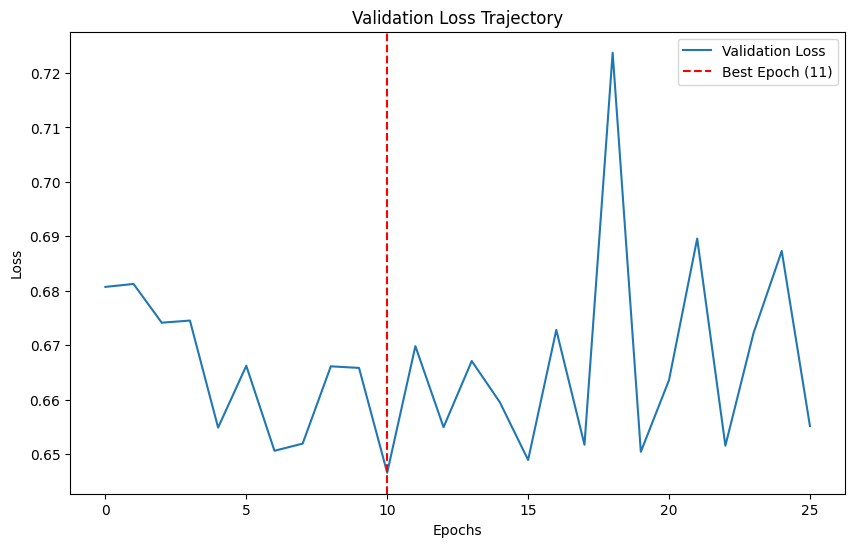

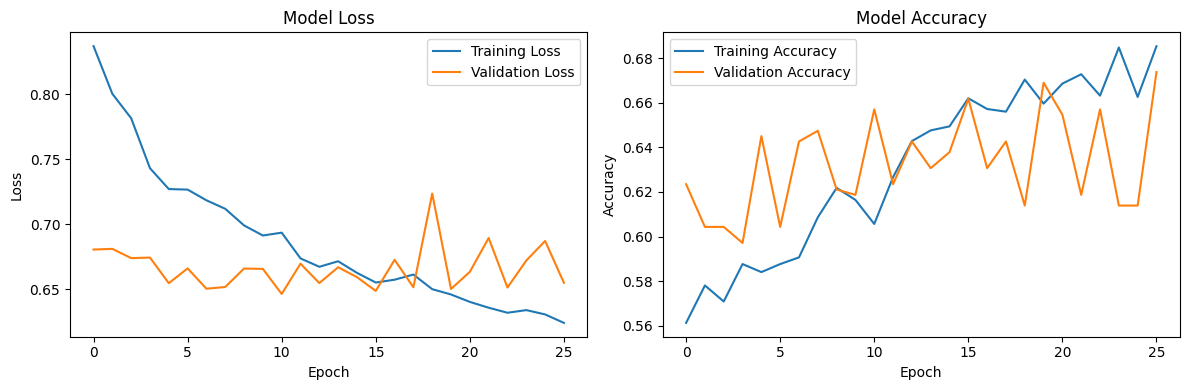


Final evaluation:
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6808 - auc: 0.7336 - loss: 0.6369 - precision: 0.7399 - recall: 0.6656
Metrics Dictionary: {'loss': 0.6423019766807556, 'compile_metrics': 0.6756237745285034}
Manually calculated accuracy: 0.6756

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.71      0.65       226
           1       0.74      0.65      0.69       295

    accuracy                           0.68       521
   macro avg       0.68      0.68      0.67       521
weighted avg       0.69      0.68      0.68       521


Test Metrics Summary:
Test loss: 0.6423
Test compile_metrics: 0.6756
Test accuracy: 0.6756


In [7]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import os
from tensorflow import keras


class EyebrowDeepfakeDetector:
    def __init__(self, model_type='lstm', input_shape=(56,7), num_classes=1):
        self.model_type = model_type
        self.input_shape = input_shape
        self.num_classes = num_classes
        self.model = self._build_model()
        self.scaler = StandardScaler()

    def _build_model(self):
        """Build and compile the model based on specified architecture type"""            
        if self.model_type == 'cnn':
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Conv1D(64, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.MaxPooling1D(2),
                tf.keras.layers.Conv1D(128, 3, activation='relu', padding='same'),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.GlobalAveragePooling1D(),
                tf.keras.layers.Dense(64, activation='relu'),
                tf.keras.layers.Dropout(0.3),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])
        elif self.model_type=="lstm":
            model = tf.keras.Sequential([
                tf.keras.layers.Input(shape=self.input_shape),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=True)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.SpatialDropout1D(0.3),
                tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(32)),
                tf.keras.layers.BatchNormalization(),
                tf.keras.layers.Dense(16, activation='relu'),
                tf.keras.layers.Dropout(0.2),
                tf.keras.layers.Dense(1, activation='sigmoid')
            ])

        elif self.model_type=="model-3":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            x = layers.Conv1D(128, kernel_size=5, padding="same", activation="relu")(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            x = layers.Conv1D(128 * 2, kernel_size=3, padding="same", activation="relu")(x)
            x = layers.BatchNormalization()(x)
            x = layers.MaxPooling1D(pool_size=2)(x)

            # BiLSTM
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=False))(x)
            x = layers.BatchNormalization()(x)

            # Dense layers
            x = layers.Dropout(0.5)(x)
            x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.5)(x)

            outputs = layers.Dense(1, activation="sigmoid")(x)

            model = models.Model(inputs, outputs)
        
        elif self.model_type=="model-4":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            # --- BiLSTM ---
            x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(inputs)
            x = layers.BatchNormalization()(x)
            x = layers.Dropout(0.5)(x)

            x = layers.Bidirectional(layers.LSTM(128))(x)
            x = layers.BatchNormalization()(x)
            x = layers.Dropout(0.4)(x)

            # --- ANN Head ---
            for units in [128,64]:
                x = layers.Dense(units, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
                x = layers.BatchNormalization()(x)
                x = layers.Dropout(0.4)(x)

            outputs = layers.Dense(1, activation='sigmoid')(x)

            model = models.Model(inputs, outputs)

        elif self.model_type=="model-5":
            from keras import layers,models,regularizers
            inputs = tf.keras.Input(shape=self.input_shape)

            # --- ANN TimeDistributed over Timesteps ---
            x = layers.TimeDistributed(layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))(inputs)
            x = layers.TimeDistributed(layers.BatchNormalization())(x)
            x = layers.TimeDistributed(layers.Dropout(0.4))(x)

            if len([64,64]) > 1:
                x = layers.TimeDistributed(layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))(x)
                x = layers.TimeDistributed(layers.BatchNormalization())(x)
                x = layers.TimeDistributed(layers.Dropout(0.4))(x)

            # --- LSTM Layer ---
            x = layers.LSTM(128, return_sequences=False)(x)
            x = layers.BatchNormalization()(x)
            x = layers.Dropout(0.4)(x)

            # --- Output ---
            x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
            x = layers.Dropout(0.4)(x)
            outputs = layers.Dense(1, activation='sigmoid')(x)

            model = models.Model(inputs, outputs)
        else:
            raise ValueError(f"Unknown model type: {self.model_type}")
            
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3,weight_decay=1e-4),
            loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
            metrics=[
                tf.keras.metrics.BinaryAccuracy(name='accuracy'),
                tf.keras.metrics.AUC(name='auc'),
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall')
            ]
        )
        return model

    def _positional_encoding(self, max_length=56, d_model=7):
        """Generate positional encoding for transformer"""
        positions = np.arange(max_length)[:, np.newaxis]
        depths = np.arange(d_model)[np.newaxis, :]/d_model
        
        angle_rates = 1 / (10000**depths)
        angle_rads = positions * angle_rates
        
        pos_encoding = np.zeros(angle_rads.shape)
        pos_encoding[:, 0::2] = np.sin(angle_rads[:, 0::2])
        pos_encoding[:, 1::2] = np.cos(angle_rads[:, 1::2])
        
        return tf.cast(pos_encoding[np.newaxis, ...], dtype=tf.float32)

    def load_data(self, csv_path):
        """Load and reshape eyebrow movement data"""
        df = pd.read_csv(csv_path, header=None)
        X = df.iloc[:, :-1].values.astype(np.float32)
        y = df.iloc[:, -1].values.astype(np.int32)
        
        # Reshape to (samples, 75, 3)
        if X.shape[1] == 392:  # Verify input dimensions
            X = X.reshape(-1, 56, 7)
        return X, y

    def preprocess_data(self, X, y, test_size=0.2):
        """Standardize features and split data"""
        # Stratified train-test split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, stratify=y, random_state=42)
        
        # Feature-wise standardization
        orig_shape = X_train.shape
        self.scaler.fit(X_train.reshape(-1, 7))
        X_train = self.scaler.transform(X_train.reshape(-1, 7)).reshape(orig_shape)
        X_test = self.scaler.transform(X_test.reshape(-1, 7)).reshape(X_test.shape)
        
        return X_train, X_test, y_train, y_test

    def train(self, X_train, y_train, X_val, y_val, epochs=100):
        """Train model with early stopping and checkpointing"""
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=15, restore_best_weights=True),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_{self.model_type}_model.keras', save_best_only=True)
        ]
        
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=64,
            callbacks=callbacks,
            verbose=2
        )

        # Print final training metrics
        print("\nFinal Training Metrics:")
        for metric in history.history:
            if not metric.startswith('val_'):
                print(f"Training {metric}: {history.history[metric][-1]:.4f}")
        
        # Print final validation metrics
        print("\nFinal Validation Metrics:")
        for metric in history.history:
            if metric.startswith('val_'):
                print(f"{metric}: {history.history[metric][-1]:.4f}")

                # Analyze stopping reason
        best_epoch = np.argmin(history.history['val_loss']) + 1
        print(f"Best model found at epoch {best_epoch}")

        # Plot validation metrics trajectory
        plt.figure(figsize=(10, 6))
        plt.plot(history.history['val_loss'], label='Validation Loss')
        plt.axvline(x=best_epoch-1, color='r', linestyle='--', 
                label=f'Best Epoch ({best_epoch})')
        plt.title('Validation Loss Trajectory')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

        return history

    def evaluate(self, X_test, y_test):
        """Comprehensive model evaluation"""
        # Quantitative metrics
        results = self.model.evaluate(X_test, y_test, verbose=1)
        metrics = dict(zip(self.model.metrics_names, results))
        
        # Debug: Print the metrics dictionary
        print("Metrics Dictionary:", metrics)
        
        # Qualitative analysis
        y_pred_prob = self.model.predict(X_test,verbose=0)
        y_pred = (y_pred_prob > 0.5).astype(int).flatten()
        
        # Calculate and print accuracy directly
        from sklearn.metrics import accuracy_score
        calc_accuracy = accuracy_score(y_test, y_pred)
        print(f"Manually calculated accuracy: {calc_accuracy:.4f}")

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred))
        
        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title('Confusion Matrix')
        plt.colorbar()
        plt.xticks([0, 1], ['Real', 'Fake'])
        plt.yticks([0, 1], ['Real', 'Fake'])
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        plt.savefig(f'{self.model_type}_confusion_matrix.png')
        plt.close()
        
        # ROC curve
        fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc:.3f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend(loc="lower right")
        plt.savefig(f'{self.model_type}_roc_curve.png')
        plt.close()
        
        # Ensure accuracy is in the metrics dictionary
        if 'accuracy' not in metrics:
            metrics['accuracy'] = calc_accuracy
        
        return metrics


# Usage example
if __name__ == "__main__":
    # Initialize detector - choose model type
    detector = EyebrowDeepfakeDetector(model_type='model-5', input_shape=(56, 7))
    
    # Load and preprocess data
    X, y = detector.load_data(os.path.join("","comprehensive_features-DeepFakeDetection_new.csv"))
    X_train, X_test, y_train, y_test = detector.preprocess_data(X, y)
    
    # Split validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)
    
    # Train model
    print("Model architecture:")
    detector.model.summary()
    history = detector.train(X_train, y_train, X_val, y_val)
    
        # Plot training history
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12, 4))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.savefig(f'{detector.model_type}_training_history.png')
    plt.show()
    plt.close('all')

    # Evaluate
    print("\nFinal evaluation:")
    test_metrics = detector.evaluate(X_test, y_test)

        # Print all metrics in a formatted way
    print("\nTest Metrics Summary:")
    for metric_name, metric_value in test_metrics.items():
        print(f"Test {metric_name}: {metric_value:.4f}")

    # Save final model
    detector.model.save(f'final_{detector.model_type}_model.keras')
